# Visualization plots for the master thesis report

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from scipy.stats import linregress

In [2]:
### Density plot
def plot_comparative_distributions(df_list, column, tittle, df_labels=None, figsize=(8, 5), show_legend=True, output_file=None, vertical_lines=None, dist_colors=None, line_colors=None):
    """
    Plots distribution curves for a specific column across multiple dataframes.
    
    df_list: List of pandas DataFrames
    column: Column name to plot (string)
    tittle: Title for the plot (string)
    df_labels: List of names for the dataframes (for the legend)
    figsize: Tuple of (width, height) for the figure size
    show_legend: Whether to display the legend (default True)
    output_file: Path to save the image for Snakemake (optional)
    vertical_lines: List of x-values where to draw vertical lines (optional)
    line_colors: List of colors for vertical lines (optional, cycles if fewer than vertical_lines)
    """
    
    # 1. Setup Labels
    if df_labels is None:
        df_labels = [f'Dataset {i+1}' for i in range(len(df_list))]
        
    if len(df_labels) != len(df_list):
        raise ValueError("Length of df_labels must match length of df_list")

    # 2. Create Figure
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    # 3. Plotting Loop
    for j, df in enumerate(df_list):
        if column in df.columns:
            color = dist_colors[j] if dist_colors and j < len(dist_colors) else None
            sns.kdeplot(
                data=df, 
                x=column, 
                label=df_labels[j], 
                ax=ax, 
                fill=True, 
                alpha=0.1,
                color=color
            )
        else:
            print(f"Warning: Column '{column}' not found in dataframe {j}")
    
    ax.set_title(tittle, fontsize=18)
    ax.set_xlabel('')
    ax.set_ylabel('Density', fontsize=18)
    ax.tick_params(axis='x', labelsize=16)
    ax.set_yticks([])
    
    # 4. Conditional Legend
    if show_legend:
        ax.legend(title="Data Source")
    
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # 5. Draw vertical lines
    if vertical_lines is not None:
        default_colors = plt.cm.tab10(range(10))
        if line_colors is None:
            line_colors = [default_colors[i % len(default_colors)] for i in range(len(vertical_lines))]
        elif len(line_colors) < len(vertical_lines):
            line_colors = [line_colors[i % len(line_colors)] for i in range(len(vertical_lines))]
        
        for x_val, color in zip(vertical_lines, line_colors):
            ax.axvline(x=x_val, color=color, linestyle='--', linewidth=3, alpha=0.7)
        
    # 6. Save logic for Snakemake
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close(fig)

In [3]:
### Correlation plot
def count_designs_in_region(df, x_col, y_col, x_range, y_range):
    """
    Counts the number of points (designs) falling within the specified rectangle.
    """
    mask = (
        (df[x_col] >= x_range[0]) & (df[x_col] <= x_range[1]) &
        (df[y_col] >= y_range[0]) & (df[y_col] <= y_range[1])
    )
    return int(mask.sum())


def plot_scatter_with_regions(df_x, df_y, x_col, y_col, x_range, y_range, title='', xlabel=None, ylabel=None, xlim=None, ylim=None, output_file=None, scale_factor=None, file_id_col='file_ID'):
    """
    Plots a single scatter plot with overlaid rectangles representing the target region 
    and an optional larger scaled region.
    
    Parameters:
    df_x: pandas DataFrame for x-axis values
    df_y: pandas DataFrame for y-axis values
    x_col: Column name for x-axis
    y_col: Column name for y-axis
    x_range: Tuple of (x_min, x_max) for the target region
    y_range: Tuple of (y_min, y_max) for the target region
    title: Optional title for the plot (default: empty string)
    xlabel: Optional x-axis label (default: None, uses x_col)
    ylabel: Optional y-axis label (default: None, uses y_col)
    xlim: Optional x-axis limits
    ylim: Optional y-axis limits
    output_file: Optional path to save the plot
    scale_factor: Optional scaling factor for a larger region. If provided, draws an additional larger rectangle.
                  For example, scale_factor=2 will draw a region twice as large, centered on the original region.
    file_id_col: Column name for file identifier to filter common files (default: 'file_ID')
    """
    
    # Filter to only include files present in both dataframes
    if file_id_col in df_x.columns and file_id_col in df_y.columns:
        common_ids = set(df_x[file_id_col]).intersection(set(df_y[file_id_col]))
        df_x_filtered = df_x[df_x[file_id_col].isin(common_ids)].reset_index(drop=True)
        df_y_filtered = df_y[df_y[file_id_col].isin(common_ids)].reset_index(drop=True)
    else:
        df_x_filtered = df_x.reset_index(drop=True)
        df_y_filtered = df_y.reset_index(drop=True)
    
    # Align dataframes and create comparison dataframe
    df = pd.DataFrame({
        x_col: df_x_filtered[x_col].values,
        y_col: df_y_filtered[y_col].values
    })
    x_col_actual = x_col
    y_col_actual = y_col
    
    # Create a single subplot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 1. Create the scatter plot
    # Use .empty and check if columns exist to avoid errors if a model failed and returned an empty df
    if not df.empty and x_col_actual in df.columns and y_col_actual in df.columns:
        ax.scatter(df[x_col_actual], df[y_col_actual], alpha=0.6, label='Data Points')
        
        # Count designs in region using the external function
        design_count = count_designs_in_region(df, x_col_actual, y_col_actual, x_range, y_range)
    else:
        design_count = 0
        ax.text(0.5, 0.5, "No Data", ha='center', va='center', transform=ax.transAxes)

    # 2. Calculate rectangle parameters
    width = x_range[1] - x_range[0]
    height = y_range[1] - y_range[0]
    
    # 3a. Draw the larger scaled region first (if scale_factor is provided)
    if scale_factor is not None and scale_factor != 0:
        center_x = (x_range[0] + x_range[1]) / 2
        center_y = (y_range[0] + y_range[1]) / 2
        scaled_width = width * (1 + scale_factor)
        scaled_height = height * (1 + scale_factor)
        scaled_x_min = center_x - scaled_width / 2
        scaled_y_min = center_y - scaled_height / 2
        scaled_rect = patches.Rectangle(
            (scaled_x_min, scaled_y_min), 
            scaled_width, scaled_height, linewidth=2, 
            edgecolor='orange', facecolor='orange', alpha=0.3, label='Scaled Region'
        )
        ax.add_patch(scaled_rect)
    
    # 3b. Create the original rectangle patch
    rect = patches.Rectangle(
        (x_range[0], y_range[0]), 
        width, height, linewidth=2, 
        edgecolor='red', facecolor='red', alpha=0.4, label='Target Region'
    )
    ax.add_patch(rect)
    
    # Add text box with the count
    text_str = f'Designs in region: {design_count}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)
    
    # 4. Apply Axis Limits
    if xlim is not None: ax.set_xlim(xlim)
    if ylim is not None: ax.set_ylim(ylim)
    
    # Formatting
    ax.set_xlabel(xlabel if xlabel is not None else x_col)
    ax.set_ylabel(ylabel if ylabel is not None else y_col)
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.7)

    plt.close(fig)

    plt.tight_layout()        

    plt.show()

    # Save or Show    else:

    if output_file:        
        plt.savefig(output_file, dpi=300, bbox_inches='tight')

In [8]:
def plot_custom_scatter(x_data, y_data, x_regions, y_regions, region_colors, title=None, xlabel=None, ylabel=None, xlim=None, ylim=None):
    """
    Plots a scatterplot with colored regions, point counts per region, and a trendline.
    Filters data to only include pairs where both x and y values are present (non-NaN).
    """
    # Convert to arrays and filter out NaN values
    x_arr = np.array(x_data)
    y_arr = np.array(y_data)
    
    # Keep only pairs where both x and y are valid (not NaN)
    valid_mask = ~(np.isnan(x_arr) | np.isnan(y_arr))
    x_arr = x_arr[valid_mask]
    y_arr = y_arr[valid_mask]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 1. Base Scatterplot (zorder=4.0)
    sns.scatterplot(x=x_arr, y=y_arr, ax=ax, color='black', alpha=0.7, zorder=4.0)
    
    # 2. Draw Regions & Count Points
    for i, ((x_min, x_max), (y_min, y_max), color) in enumerate(zip(x_regions, y_regions, region_colors)):
        
        width = x_max - x_min
        height = y_max - y_min
        
        rgb = mcolors.to_rgb(color)
        pastel_facecolor = tuple(c * 0.2 + 1.0 * 0.8 for c in rgb)
        
        # PATCH FIX: Use tiny decimal increments (1.1, 1.2, 1.3)
        rect = patches.Rectangle(
            (x_min, y_min), width, height, 
            linewidth=1.5, edgecolor=color, facecolor=pastel_facecolor, alpha=1.0, zorder=1.1 + (i * 0.1)
        )
        ax.add_patch(rect)
        
        in_region = (x_arr >= x_min) & (x_arr <= x_max) & (y_arr >= y_min) & (y_arr <= y_max)
        count = np.sum(in_region)
        
        center_x = x_min + (width / 2)
        center_y = y_min + (height / 2)
        
        # Text (zorder=5.0)
        ax.text(
            center_x, center_y, f'n={count}', 
            ha='center', va='center', fontsize=12, fontweight='bold', 
            color='black', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round'),
            zorder=5.0
        )

    # 3. Fit Line and Calculate Statistics
    slope, intercept, r_value, p_value, std_err = linregress(x_arr, y_arr)
    r_squared = r_value**2
    
    x_line = np.linspace(x_arr.min(), x_arr.max(), 100)
    y_line = slope * x_line + intercept
    
    # Trendline (zorder=3.0)
    ax.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, zorder=3.0, label='Trendline')
    
    # 4. Display Stats Box (zorder=5.0)
    stats_text = f'$R^2$ = {r_squared:.3f}\nSlope = {slope:.3f}'
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
    
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props, zorder=5.0)
    
    plt.title(title if title is not None else "Scatterplot with Custom Regions and Trendline")
    plt.xlabel(xlabel if xlabel is not None else "X Axis")
    plt.ylabel(ylabel if ylabel is not None else "Y Axis")
    
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    plt.legend(loc='lower right')
    
    # --- GRID FIX ---
    # ax.set_axisbelow(False) forces the grid above patches that have standard low zorders
    ax.set_axisbelow(False) 

    # Set Grid to zorder=2.0 (higher than the 1.1/1.2 patches, lower than everything else)    

    plt.grid(True, linestyle=':', alpha=0.6, zorder=2.0)    
    plt.show()

    return slope, r_squared

    
    

### Dataframe loading

The path to each ligand is: (replicate 2 is the same but saying conformer 1)
- tdc /proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1404_TDC_conformer_0
- 9ad /proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1604_9AD_conformer0
- emo /proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1604_EMO_conformer_0
- rhe /proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1604_RHE_conformer_0
- ipt /proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/2P9H_IPT_conformer0
- xyl /proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/2P9H_XYL_conformer0
- cbs /proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/2P9H_CBS_conformer0
- mev /proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/2P9H_MEV_conformer0

The file for each model should be:
- esm path/checkpoints/ESM_metrics_combined.csv
- fold path/CHAI_predictions.csv
- cofold path/CHAI_cofold.csv
- boltz path/BOLTZ_predictions.csv
- boltz_native path/BOLTZ_native_metrics.csv


In [2]:
### TDC
tdc_path_r1 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1404_TDC_conformer_0"
tdc_path_r2 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1404_TDC_conformer_1"

tdc_df_replicate_1_esm = pd.read_csv(f"{tdc_path_r1}/checkpoints/ESM_metrics_combined.csv")
tdc_df_replicate_1_fold = pd.read_csv(f"{tdc_path_r1}/CHAI_predictions.csv")
tdc_df_replicate_1_cofold = pd.read_csv(f"{tdc_path_r1}/CHAI_cofold.csv")
tdc_df_replicate_1_boltz = pd.read_csv(f"{tdc_path_r1}/BOLTZ_predictions.csv")
tdc_df_replicate_1_boltz_native = pd.read_csv("/proj/berzelius-2023-361/users/x_eduam/TDC_boltz.csv")

tdc_df_replicate_2_esm = pd.read_csv(f"{tdc_path_r2}/checkpoints/ESM_metrics_combined.csv")
tdc_df_replicate_2_fold = pd.read_csv(f"{tdc_path_r2}/CHAI_predictions.csv")
tdc_df_replicate_2_cofold = pd.read_csv(f"{tdc_path_r2}/CHAI_cofold.csv")
tdc_df_replicate_2_boltz = pd.read_csv(f"{tdc_path_r2}/BOLTZ_predictions.csv")
tdc_df_replicate_2_boltz_native = pd.read_csv(f"{tdc_path_r2}/BOLTZ_native_metrics.csv")

### 9AD
nad_path_r1 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1604_9AD_conformer0"
nad_path_r2 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1604_9AD_conformer1"

nad_df_replicate_1_esm = pd.read_csv(f"{nad_path_r1}/checkpoints/ESM_metrics_combined.csv")
nad_df_replicate_1_fold = pd.read_csv(f"{nad_path_r1}/CHAI_predictions.csv")
nad_df_replicate_1_cofold = pd.read_csv(f"{nad_path_r1}/CHAI_cofold.csv")
nad_df_replicate_1_boltz = pd.read_csv(f"{nad_path_r1}/BOLTZ_predictions.csv")
nad_df_replicate_1_boltz_native = pd.read_csv(f"{nad_path_r1}/BOLTZ_native_metrics.csv")

nad_df_replicate_2_esm = pd.read_csv(f"{nad_path_r2}/checkpoints/ESM_metrics_combined.csv")
nad_df_replicate_2_fold = pd.read_csv(f"{nad_path_r2}/CHAI_predictions.csv")
nad_df_replicate_2_cofold = pd.read_csv(f"{nad_path_r2}/CHAI_cofold.csv")
nad_df_replicate_2_boltz = pd.read_csv(f"{nad_path_r2}/BOLTZ_predictions.csv")
nad_df_replicate_2_boltz_native = pd.read_csv(f"{nad_path_r2}/BOLTZ_native_metrics.csv")

### Emodin
emo_path_r1 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1604_EMO_conformer_0"
emo_path_r2 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1604_EMO_conformer_1"

emo_df_replicate_1_esm = pd.read_csv(f"{emo_path_r1}/checkpoints/ESM_metrics_combined.csv")
emo_df_replicate_1_fold = pd.read_csv(f"{emo_path_r1}/CHAI_predictions.csv")
emo_df_replicate_1_cofold = pd.read_csv(f"{emo_path_r1}/CHAI_cofold.csv")
emo_df_replicate_1_boltz = pd.read_csv(f"{emo_path_r1}/BOLTZ_predictions.csv")
emo_df_replicate_1_boltz_native = pd.read_csv(f"{emo_path_r1}/BOLTZ_native_metrics.csv")

emo_df_replicate_2_esm = pd.read_csv(f"{emo_path_r2}/checkpoints/ESM_metrics_combined.csv")
emo_df_replicate_2_fold = pd.read_csv(f"{emo_path_r2}/CHAI_predictions.csv")
emo_df_replicate_2_cofold = pd.read_csv(f"{emo_path_r2}/CHAI_cofold.csv")
emo_df_replicate_2_boltz = pd.read_csv(f"{emo_path_r2}/BOLTZ_predictions.csv")
emo_df_replicate_2_boltz_native = pd.read_csv(f"{emo_path_r2}/BOLTZ_native_metrics.csv")

### Rhein
rhein_path_r1 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1604_RHE_conformer_0"
rhein_path_r2 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1604_RHE_conformer_1"

rhein_df_replicate_1_esm = pd.read_csv(f"{rhein_path_r1}/checkpoints/ESM_metrics_combined.csv")
rhein_df_replicate_1_fold = pd.read_csv(f"{rhein_path_r1}/CHAI_predictions.csv")
rhein_df_replicate_1_cofold = pd.read_csv(f"{rhein_path_r1}/CHAI_cofold.csv")
rhein_df_replicate_1_boltz = pd.read_csv(f"{rhein_path_r1}/BOLTZ_predictions.csv")
rhein_df_replicate_1_boltz_native = pd.read_csv(f"{rhein_path_r1}/BOLTZ_native_metrics.csv")

rhein_df_replicate_2_esm = pd.read_csv(f"{rhein_path_r2}/checkpoints/ESM_metrics_combined.csv")
rhein_df_replicate_2_fold = pd.read_csv(f"{rhein_path_r2}/CHAI_predictions.csv")
rhein_df_replicate_2_cofold = pd.read_csv(f"{rhein_path_r2}/CHAI_cofold.csv")
rhein_df_replicate_2_boltz = pd.read_csv(f"{rhein_path_r2}/BOLTZ_predictions.csv")
rhein_df_replicate_2_boltz_native = pd.read_csv(f"{rhein_path_r2}/BOLTZ_native_metrics.csv")

In [3]:
### IPTG
ipt_path_r1 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1905_2P9H_IPT_conformer0"
ipt_path_r2 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1905_2P9H_IPT_conformer1"

ipt_df_replicate_1_esm = pd.read_csv(f"{ipt_path_r1}/checkpoints/ESM_metrics_combined.csv")
ipt_df_replicate_1_fold = pd.read_csv(f"{ipt_path_r1}/CHAI_predictions.csv")
ipt_df_replicate_1_cofold = pd.read_csv(f"{ipt_path_r1}/CHAI_cofold.csv")
ipt_df_replicate_1_boltz = pd.read_csv(f"{ipt_path_r1}/BOLTZ_predictions.csv")
ipt_df_replicate_1_boltz_native = pd.read_csv(f"{ipt_path_r1}/BOLTZ_native_metrics.csv")

ipt_df_replicate_2_esm = pd.read_csv(f"{ipt_path_r2}/checkpoints/ESM_metrics_combined.csv")
ipt_df_replicate_2_fold = pd.read_csv(f"{ipt_path_r2}/CHAI_predictions.csv")
ipt_df_replicate_2_cofold = pd.read_csv(f"{ipt_path_r2}/CHAI_cofold.csv")
ipt_df_replicate_2_boltz = pd.read_csv(f"{ipt_path_r2}/BOLTZ_predictions.csv")
ipt_df_replicate_2_boltz_native = pd.read_csv(f"{ipt_path_r2}/BOLTZ_native_metrics.csv")

### Xylose
xyl_path_r1 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1905_2P9H_XYL_conformer0"
xyl_path_r2 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/2P9H_XYL_conformer1"

xyl_df_replicate_1_esm = pd.read_csv(f"{xyl_path_r1}/checkpoints/ESM_metrics_combined.csv")
xyl_df_replicate_1_fold = pd.read_csv(f"{xyl_path_r1}/CHAI_predictions.csv")
xyl_df_replicate_1_cofold = pd.read_csv(f"{xyl_path_r1}/CHAI_cofold.csv")
xyl_df_replicate_1_boltz = pd.read_csv(f"{xyl_path_r1}/BOLTZ_predictions.csv")
xyl_df_replicate_1_boltz_native = pd.read_csv(f"{xyl_path_r1}/BOLTZ_native_metrics.csv")

xyl_df_replicate_2_esm = pd.read_csv(f"{xyl_path_r2}/checkpoints/ESM_metrics_combined.csv")
xyl_df_replicate_2_fold = pd.read_csv(f"{xyl_path_r2}/CHAI_predictions.csv")
xyl_df_replicate_2_cofold = pd.read_csv(f"{xyl_path_r2}/CHAI_cofold.csv")
xyl_df_replicate_2_boltz = pd.read_csv(f"{xyl_path_r2}/BOLTZ_predictions.csv")
xyl_df_replicate_2_boltz_native = pd.read_csv(f"{xyl_path_r2}/BOLTZ_native_metrics.csv")

### Cellobiose
cbs_path_r1 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1905_2P9H_CBS_conformer0"
cbs_path_r2 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1905_2P9H_CBS_conformer1"

cbs_df_replicate_1_esm = pd.read_csv(f"{cbs_path_r1}/checkpoints/ESM_metrics_combined.csv")
cbs_df_replicate_1_fold = pd.read_csv(f"{cbs_path_r1}/CHAI_predictions.csv")
cbs_df_replicate_1_cofold = pd.read_csv(f"{cbs_path_r1}/CHAI_cofold.csv")
cbs_df_replicate_1_boltz = pd.read_csv(f"{cbs_path_r1}/BOLTZ_predictions.csv")
cbs_df_replicate_1_boltz_native = pd.read_csv(f"{cbs_path_r1}/BOLTZ_native_metrics.csv")

cbs_df_replicate_2_esm = pd.read_csv(f"{cbs_path_r2}/checkpoints/ESM_metrics_combined.csv")
cbs_df_replicate_2_fold = pd.read_csv(f"{cbs_path_r2}/CHAI_predictions.csv")
cbs_df_replicate_2_cofold = pd.read_csv(f"{cbs_path_r2}/CHAI_cofold.csv")
cbs_df_replicate_2_boltz = pd.read_csv(f"{cbs_path_r2}/BOLTZ_predictions.csv")
cbs_df_replicate_2_boltz_native = pd.read_csv(f"{cbs_path_r2}/BOLTZ_native_metrics.csv")

### Mevalonate
mev_path_r1 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1905_2P9H_MEV_conformer0"
mev_path_r2 = "/proj/berzelius-2023-361/users/x_eduam/strategy_1_campaign/runs/1905_2P9H_MEV_conformer1"

mev_df_replicate_1_esm = pd.read_csv(f"{mev_path_r1}/checkpoints/ESM_metrics_combined.csv")
mev_df_replicate_1_fold = pd.read_csv(f"{mev_path_r1}/CHAI_predictions.csv")
mev_df_replicate_1_cofold = pd.read_csv(f"{mev_path_r1}/CHAI_cofold.csv")
mev_df_replicate_1_boltz = pd.read_csv(f"{mev_path_r1}/BOLTZ_predictions.csv")
mev_df_replicate_1_boltz_native = pd.read_csv(f"{mev_path_r1}/BOLTZ_native_metrics.csv")

mev_df_replicate_2_esm = pd.read_csv(f"{mev_path_r2}/checkpoints/ESM_metrics_combined.csv")
mev_df_replicate_2_fold = pd.read_csv(f"{mev_path_r2}/CHAI_predictions.csv")
mev_df_replicate_2_cofold = pd.read_csv(f"{mev_path_r2}/CHAI_cofold.csv")
mev_df_replicate_2_boltz = pd.read_csv(f"{mev_path_r2}/BOLTZ_predictions.csv")
mev_df_replicate_2_boltz_native = pd.read_csv(f"{mev_path_r2}/BOLTZ_native_metrics.csv")

## Density distribution plots

For each ligand I wanna have plots with:
- pLDDT is "pLDDT_mean"
- TM score is "TMscore"
- CNN_score is "Gnina_CNNscore"
- CNN_affinity "Gnina_affinity"
- Boltz binary "affinity_probability_binary" 
- Boltz affinity pred "affinity_pred_value"

For boltz binary and affinity pred, the dataframe list should contain only the corresponding boltz native dataframe and therefore, color '#D62728'

### TDC

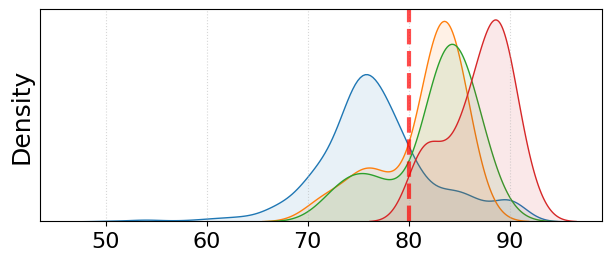

In [5]:
# pLDDT
plot_comparative_distributions([tdc_df_replicate_1_esm,tdc_df_replicate_1_fold, tdc_df_replicate_1_cofold, tdc_df_replicate_1_boltz], "pLDDT_mean", tittle ="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[80], dist_colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

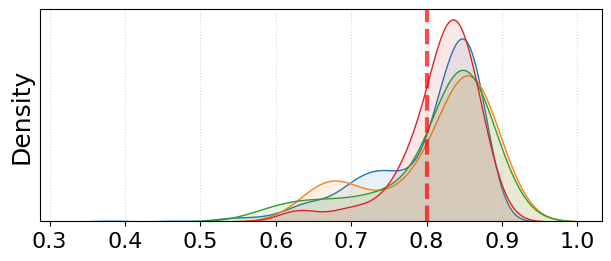

In [6]:
# TM_score
plot_comparative_distributions([tdc_df_replicate_1_esm, tdc_df_replicate_1_fold, tdc_df_replicate_1_cofold, tdc_df_replicate_1_boltz], "TMscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.8], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

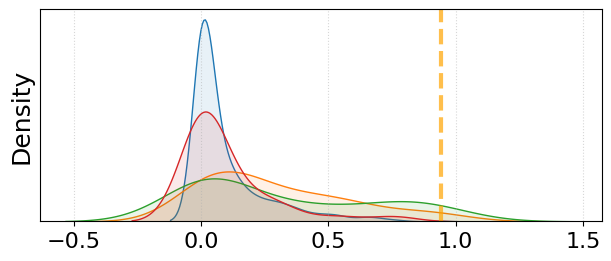

In [7]:
# Gnina cnn_score
plot_comparative_distributions([tdc_df_replicate_1_esm, tdc_df_replicate_1_fold, tdc_df_replicate_1_cofold, tdc_df_replicate_1_boltz], "Gnina_CNNscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.94421], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange'])

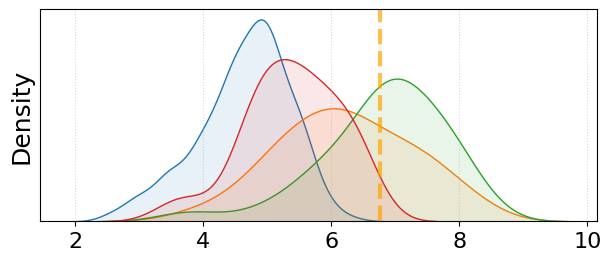

In [8]:
#Gnina affinity score
plot_comparative_distributions([tdc_df_replicate_1_esm, tdc_df_replicate_1_fold, tdc_df_replicate_1_cofold, tdc_df_replicate_1_boltz], "Gnina_affinity", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[6.75738], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange'])

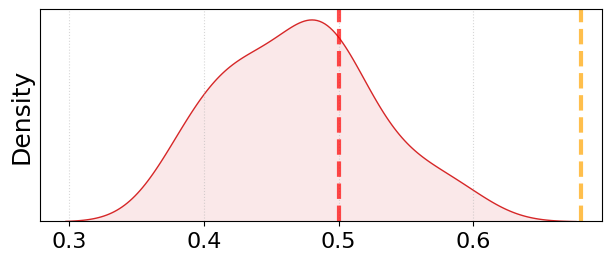

In [6]:
#Boltz binary
plot_comparative_distributions([tdc_df_replicate_1_boltz_native], "affinity_probability_binary", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.5,0.68], dist_colors=['#D62728'], line_colors=['red', 'orange'])

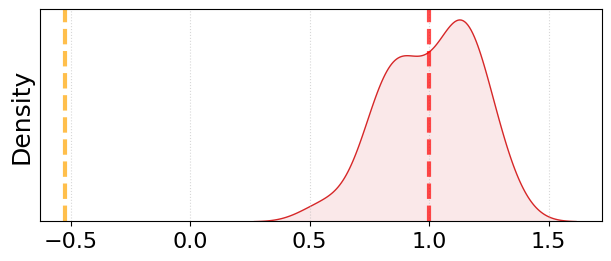

In [7]:
#Boltz affinity prob
plot_comparative_distributions([tdc_df_replicate_1_boltz_native], "affinity_pred_value", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[1,-0.523], dist_colors=['#D62728'], line_colors=['red', 'orange'])

### 9AD

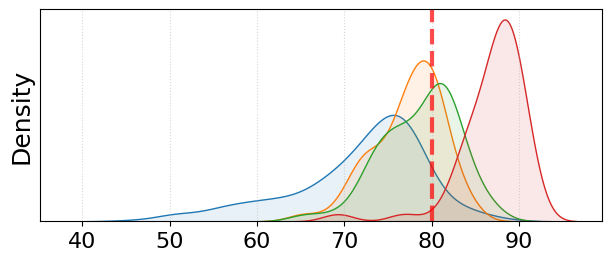

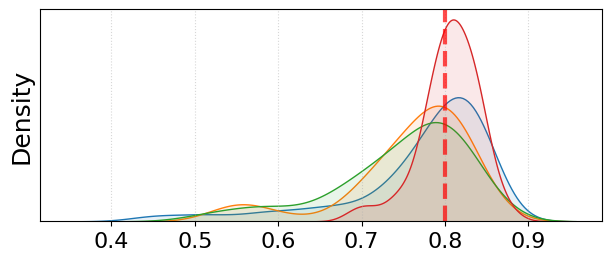

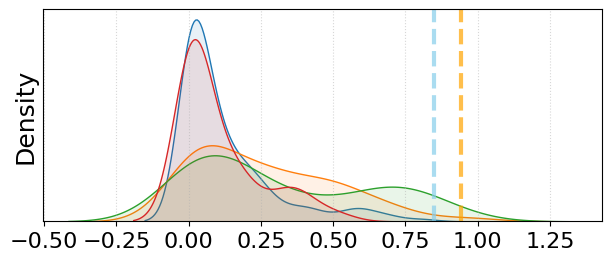

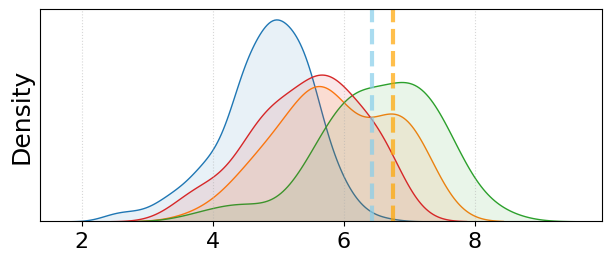

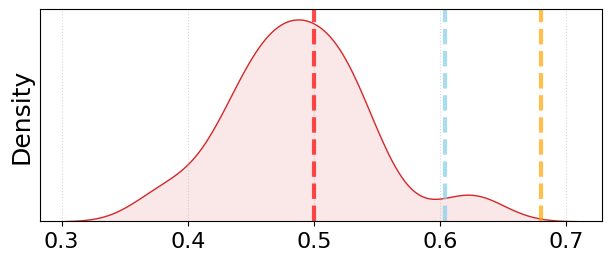

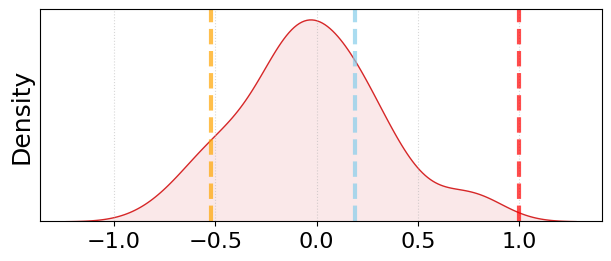

In [7]:
# pLDDT
plot_comparative_distributions([nad_df_replicate_1_esm, nad_df_replicate_1_fold, nad_df_replicate_1_cofold, nad_df_replicate_1_boltz], "pLDDT_mean", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[80], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# TM_score
plot_comparative_distributions([nad_df_replicate_1_esm, nad_df_replicate_1_fold, nad_df_replicate_1_cofold, nad_df_replicate_1_boltz], "TMscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.8], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# Gnina cnn_score
plot_comparative_distributions([nad_df_replicate_1_esm, nad_df_replicate_1_fold, nad_df_replicate_1_cofold, nad_df_replicate_1_boltz], "Gnina_CNNscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.94421, 0.85], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange','skyblue'])

# Gnina affinity score
plot_comparative_distributions([nad_df_replicate_1_esm, nad_df_replicate_1_fold, nad_df_replicate_1_cofold, nad_df_replicate_1_boltz], "Gnina_affinity", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[6.75738,6.43], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange','skyblue'])

# Boltz binary
plot_comparative_distributions([nad_df_replicate_1_boltz_native], "affinity_probability_binary", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.5,0.68, 0.604], dist_colors=['#D62728'], line_colors=['red', 'orange','skyblue'])

# Boltz affinity prob
plot_comparative_distributions([nad_df_replicate_1_boltz_native], "affinity_pred_value", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[1,-0.523,0.188], dist_colors=['#D62728'], line_colors=['red', 'orange', 'skyblue'])

### Emodin

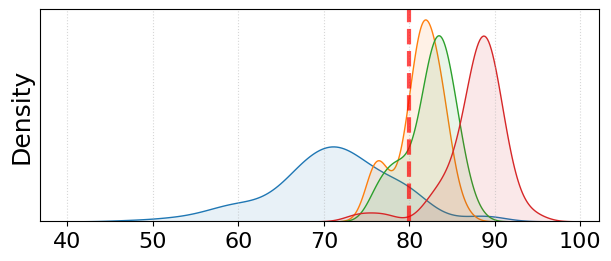

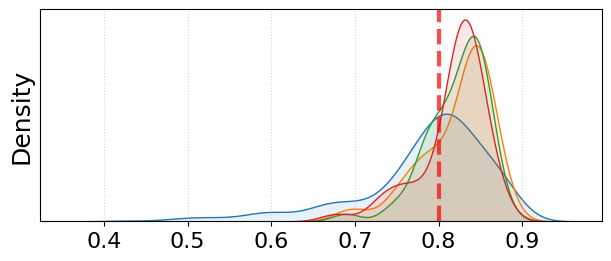

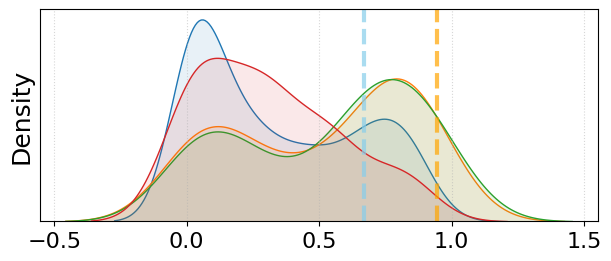

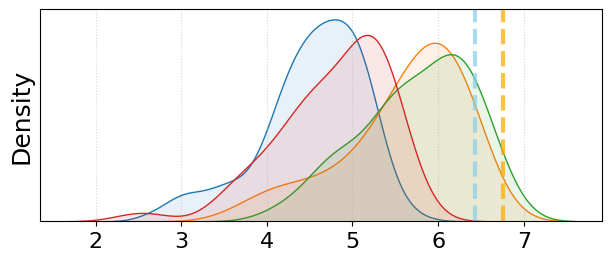

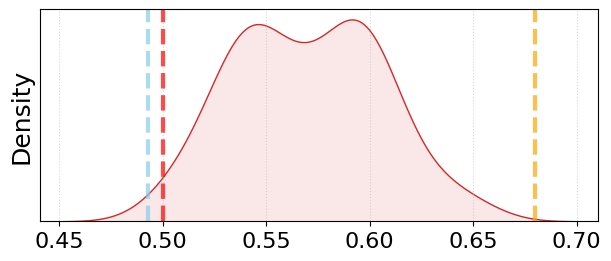

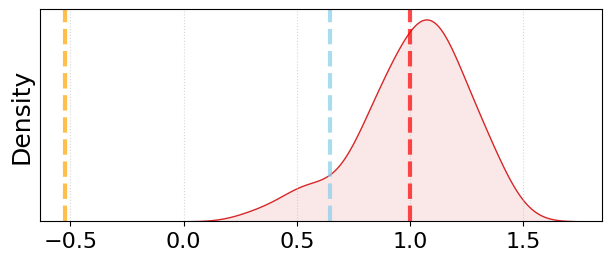

In [8]:
# pLDDT
plot_comparative_distributions([emo_df_replicate_1_esm, emo_df_replicate_1_fold, emo_df_replicate_1_cofold, emo_df_replicate_1_boltz], "pLDDT_mean", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[80], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# TM_score
plot_comparative_distributions([emo_df_replicate_1_esm, emo_df_replicate_1_fold, emo_df_replicate_1_cofold, emo_df_replicate_1_boltz], "TMscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.8], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# Gnina cnn_score
plot_comparative_distributions([emo_df_replicate_1_esm, emo_df_replicate_1_fold, emo_df_replicate_1_cofold, emo_df_replicate_1_boltz], "Gnina_CNNscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.94421,0.671], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange', 'skyblue'])

# Gnina affinity score
plot_comparative_distributions([emo_df_replicate_1_esm, emo_df_replicate_1_fold, emo_df_replicate_1_cofold, emo_df_replicate_1_boltz], "Gnina_affinity", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[6.75738,6.43], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange','skyblue'])

# Boltz binary
plot_comparative_distributions([emo_df_replicate_1_boltz_native], "affinity_probability_binary", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.5,0.68,0.493], dist_colors=['#D62728'], line_colors=['red', 'orange', 'skyblue'])

# Boltz affinity prob
plot_comparative_distributions([emo_df_replicate_1_boltz_native], "affinity_pred_value", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[1,-0.523,0.645], dist_colors=['#D62728'], line_colors=['red', 'orange','skyblue'])

### Rhein

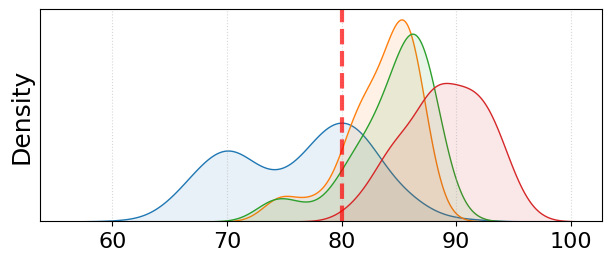

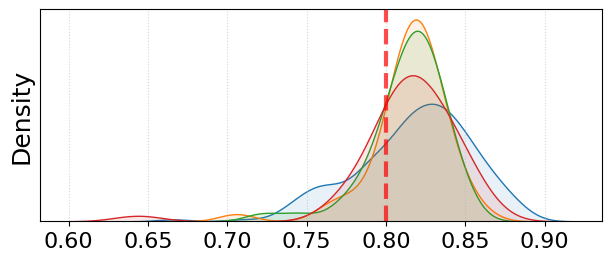

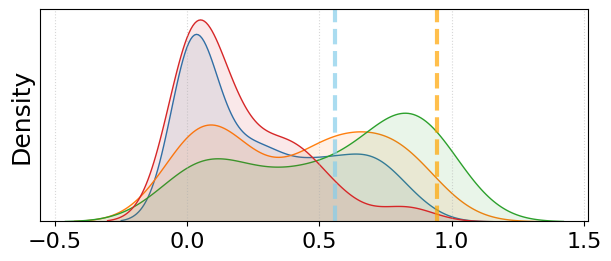

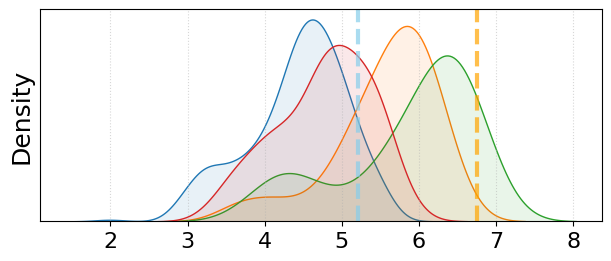

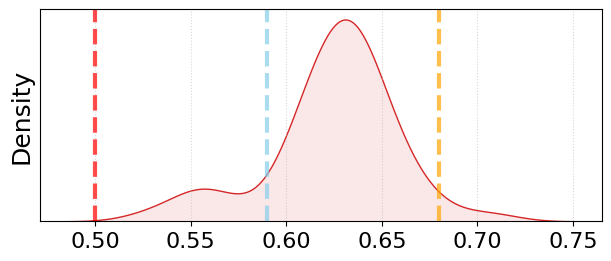

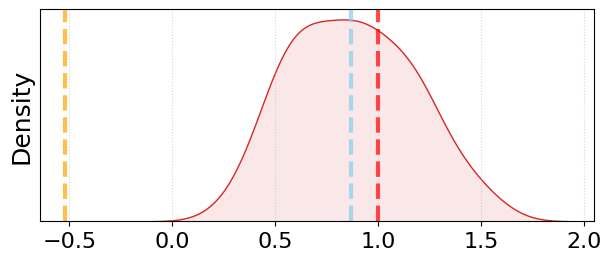

In [9]:
# pLDDT
plot_comparative_distributions([rhein_df_replicate_1_esm, rhein_df_replicate_1_fold, rhein_df_replicate_1_cofold, rhein_df_replicate_1_boltz], "pLDDT_mean", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[80], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# TM_score
plot_comparative_distributions([rhein_df_replicate_1_esm, rhein_df_replicate_1_fold, rhein_df_replicate_1_cofold, rhein_df_replicate_1_boltz], "TMscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.8], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# Gnina cnn_score
plot_comparative_distributions([rhein_df_replicate_1_esm, rhein_df_replicate_1_fold, rhein_df_replicate_1_cofold, rhein_df_replicate_1_boltz], "Gnina_CNNscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.94421,0.561], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange','skyblue'])

# Gnina affinity score
plot_comparative_distributions([rhein_df_replicate_1_esm, rhein_df_replicate_1_fold, rhein_df_replicate_1_cofold, rhein_df_replicate_1_boltz], "Gnina_affinity", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[6.75738, 5.21], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange','skyblue'])

# Boltz binary
plot_comparative_distributions([rhein_df_replicate_1_boltz_native], "affinity_probability_binary", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.5,0.68, 0.59], dist_colors=['#D62728'], line_colors=['red', 'orange','skyblue'])

# Boltz affinity prob
plot_comparative_distributions([rhein_df_replicate_1_boltz_native], "affinity_pred_value", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[1,-0.523,0.87], dist_colors=['#D62728'], line_colors=['red', 'orange','skyblue'])

### IPTG

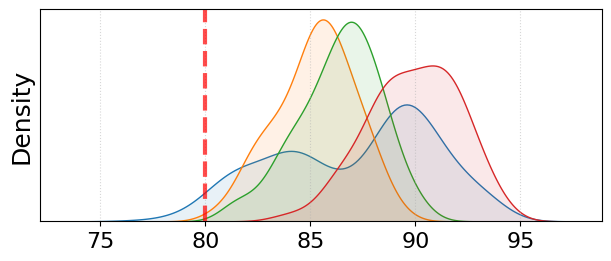

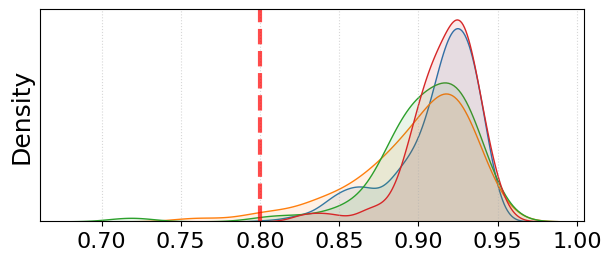

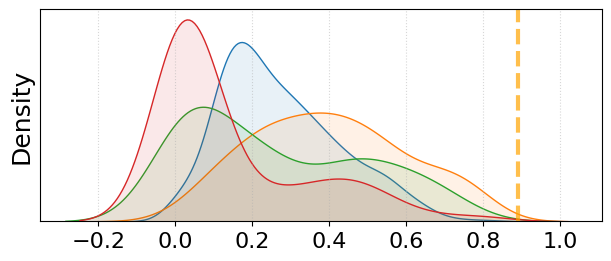

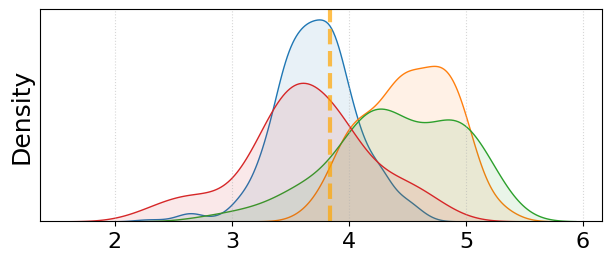

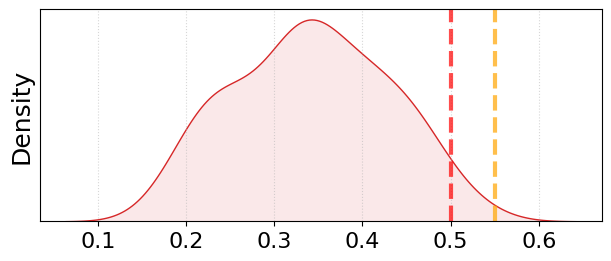

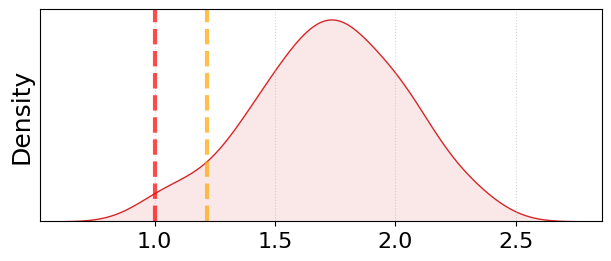

In [18]:
# pLDDT
plot_comparative_distributions([ipt_df_replicate_1_esm, ipt_df_replicate_1_fold, ipt_df_replicate_1_cofold, ipt_df_replicate_1_boltz], "pLDDT_mean", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[80], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# TM_score
plot_comparative_distributions([ipt_df_replicate_1_esm, ipt_df_replicate_1_fold, ipt_df_replicate_1_cofold, ipt_df_replicate_1_boltz], "TMscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.8], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# Gnina cnn_score
plot_comparative_distributions([ipt_df_replicate_1_esm, ipt_df_replicate_1_fold, ipt_df_replicate_1_cofold, ipt_df_replicate_1_boltz], "Gnina_CNNscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.89089], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange'])

# Gnina affinity score
plot_comparative_distributions([ipt_df_replicate_1_esm, ipt_df_replicate_1_fold, ipt_df_replicate_1_cofold, ipt_df_replicate_1_boltz], "Gnina_affinity", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[3.83604], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange'])

# Boltz binary
plot_comparative_distributions([ipt_df_replicate_1_boltz_native], "affinity_probability_binary", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.5,0.5506], dist_colors=['#D62728'], line_colors=['red', 'orange'])

# Boltz affinity prob
plot_comparative_distributions([ipt_df_replicate_1_boltz_native], "affinity_pred_value", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[1,1.2175], dist_colors=['#D62728'], line_colors=['red', 'orange'])

### Xylose

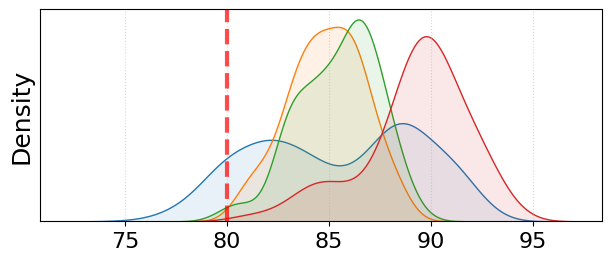

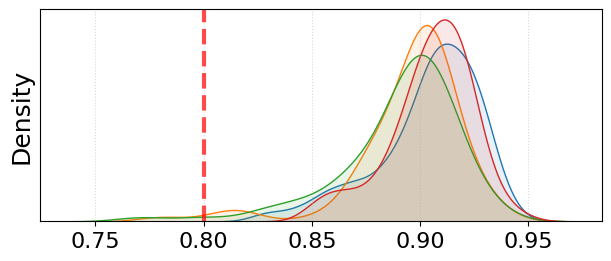

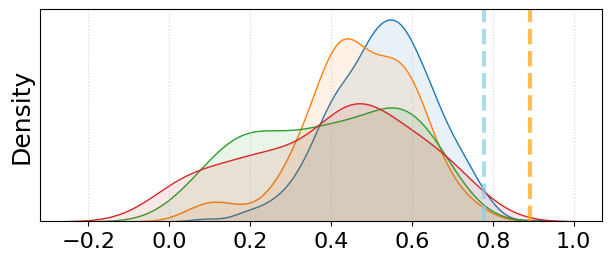

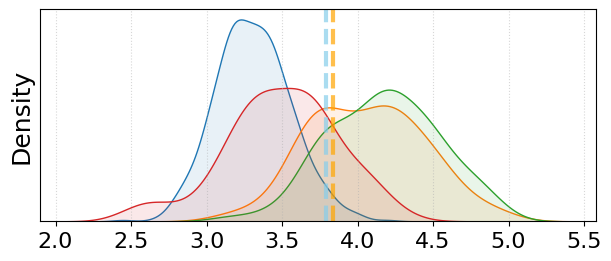

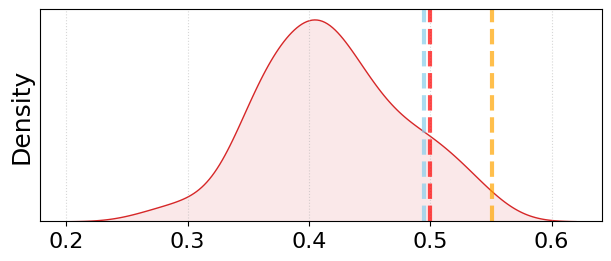

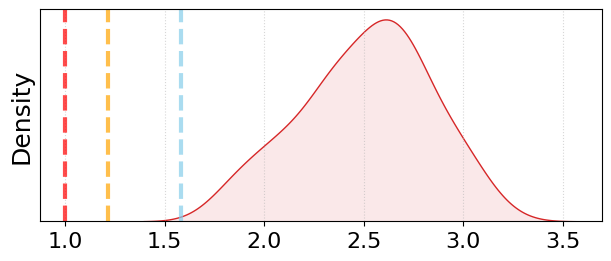

In [10]:
# pLDDT
plot_comparative_distributions([xyl_df_replicate_1_esm, xyl_df_replicate_1_fold, xyl_df_replicate_1_cofold, xyl_df_replicate_1_boltz], "pLDDT_mean", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[80], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# TM_score
plot_comparative_distributions([xyl_df_replicate_1_esm, xyl_df_replicate_1_fold, xyl_df_replicate_1_cofold, xyl_df_replicate_1_boltz], "TMscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.8], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# Gnina cnn_score
plot_comparative_distributions([xyl_df_replicate_1_esm, xyl_df_replicate_1_fold, xyl_df_replicate_1_cofold, xyl_df_replicate_1_boltz], "Gnina_CNNscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.89089,0.778], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange', 'skyblue'])

# Gnina affinity score
plot_comparative_distributions([xyl_df_replicate_1_esm, xyl_df_replicate_1_fold, xyl_df_replicate_1_cofold, xyl_df_replicate_1_boltz], "Gnina_affinity", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[3.83604,3.79], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange', 'skyblue'])

# Boltz binary
plot_comparative_distributions([xyl_df_replicate_1_boltz_native], "affinity_probability_binary", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.5,0.5506,0.495], dist_colors=['#D62728'], line_colors=['red', 'orange', 'skyblue'])

# Boltz affinity prob
plot_comparative_distributions([xyl_df_replicate_1_boltz_native], "affinity_pred_value", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[1,1.2175,1.58], dist_colors=['#D62728'], line_colors=['red', 'orange', 'skyblue'])

### Cellobiose

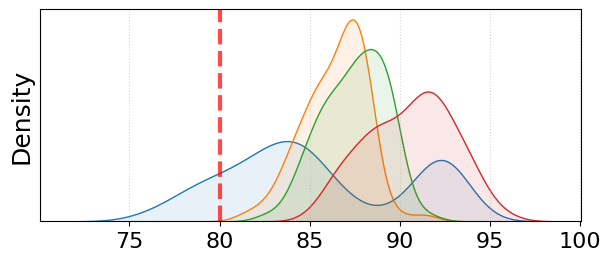

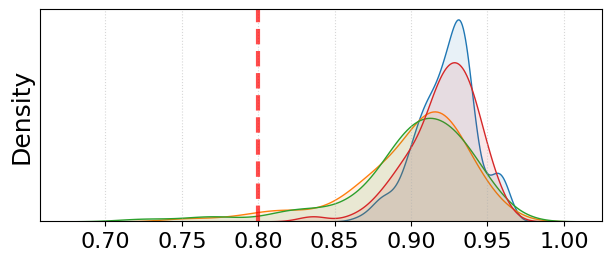

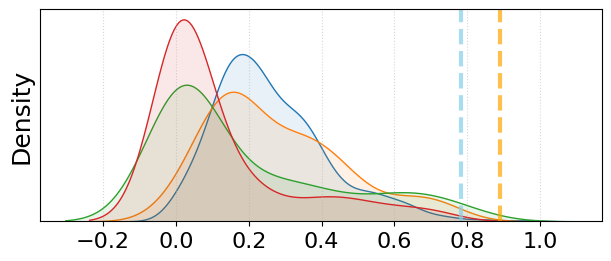

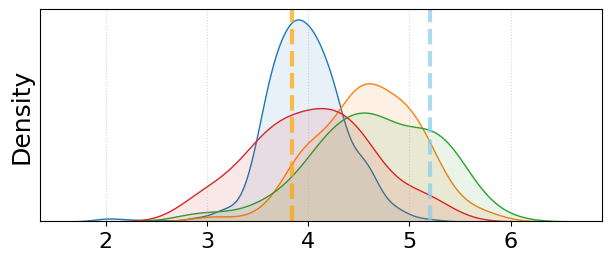

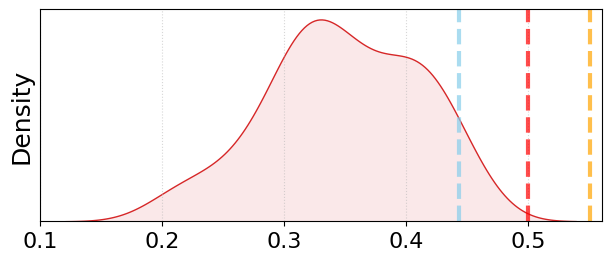

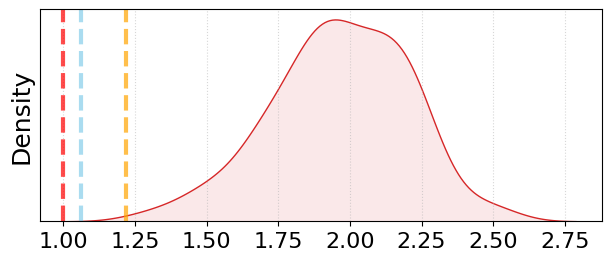

In [11]:
# pLDDT
plot_comparative_distributions([cbs_df_replicate_1_esm, cbs_df_replicate_1_fold, cbs_df_replicate_1_cofold, cbs_df_replicate_1_boltz], "pLDDT_mean", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[80], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# TM_score
plot_comparative_distributions([cbs_df_replicate_1_esm, cbs_df_replicate_1_fold, cbs_df_replicate_1_cofold, cbs_df_replicate_1_boltz], "TMscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.8], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# Gnina cnn_score
plot_comparative_distributions([cbs_df_replicate_1_esm, cbs_df_replicate_1_fold, cbs_df_replicate_1_cofold, cbs_df_replicate_1_boltz], "Gnina_CNNscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.89089,0.783], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange','skyblue'])

# Gnina affinity score
plot_comparative_distributions([cbs_df_replicate_1_esm, cbs_df_replicate_1_fold, cbs_df_replicate_1_cofold, cbs_df_replicate_1_boltz], "Gnina_affinity", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[3.83604,5.20], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange','skyblue'])

# Boltz binary
plot_comparative_distributions([cbs_df_replicate_1_boltz_native], "affinity_probability_binary", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.5,0.5506,0.443], dist_colors=['#D62728'], line_colors=['red', 'orange','skyblue'])

# Boltz affinity prob
plot_comparative_distributions([cbs_df_replicate_1_boltz_native], "affinity_pred_value", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[1,1.2175, 1.06], dist_colors=['#D62728'], line_colors=['red', 'orange','skyblue'])

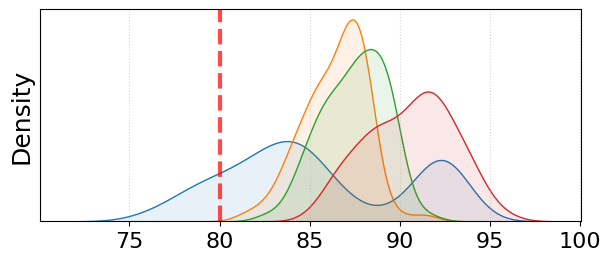

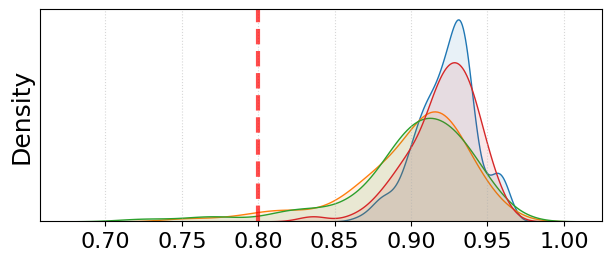

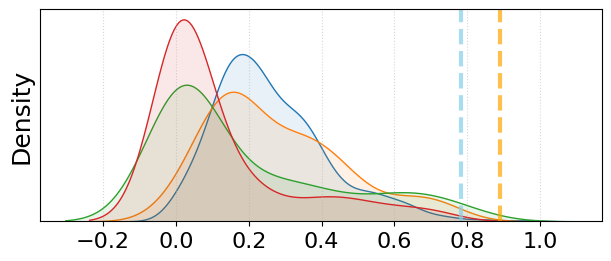

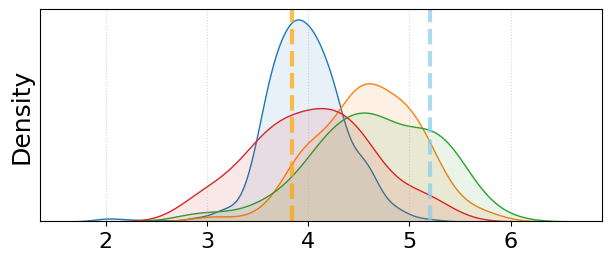

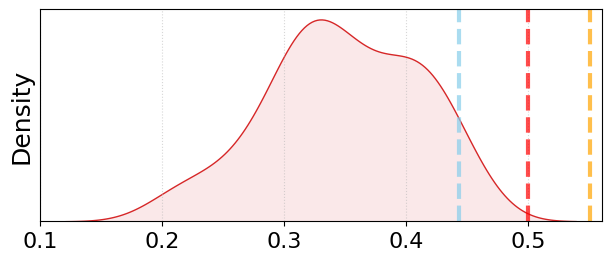

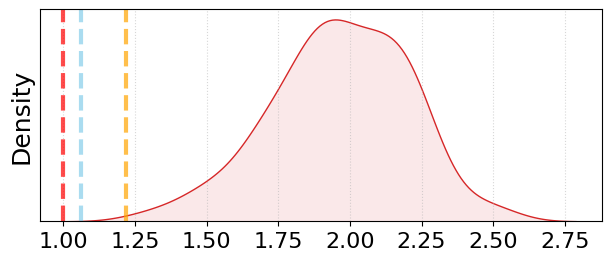

In [ ]:
# pLDDT
plot_comparative_distributions([cbs_df_replicate_1_esm, cbs_df_replicate_1_fold, cbs_df_replicate_1_cofold, cbs_df_replicate_1_boltz], "pLDDT_mean", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[80], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# TM_score
plot_comparative_distributions([cbs_df_replicate_1_esm, cbs_df_replicate_1_fold, cbs_df_replicate_1_cofold, cbs_df_replicate_1_boltz], "TMscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.8], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# Gnina cnn_score
plot_comparative_distributions([cbs_df_replicate_1_esm, cbs_df_replicate_1_fold, cbs_df_replicate_1_cofold, cbs_df_replicate_1_boltz], "Gnina_CNNscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.89089,0.783], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange','skyblue'])

# Gnina affinity score
plot_comparative_distributions([cbs_df_replicate_1_esm, cbs_df_replicate_1_fold, cbs_df_replicate_1_cofold, cbs_df_replicate_1_boltz], "Gnina_affinity", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[3.83604,5.20], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange','skyblue'])

# Boltz binary
plot_comparative_distributions([cbs_df_replicate_1_boltz_native], "affinity_probability_binary", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.5,0.5506,0.443], dist_colors=['#D62728'], line_colors=['red', 'orange','skyblue'])

# Boltz affinity prob
plot_comparative_distributions([cbs_df_replicate_1_boltz_native], "affinity_pred_value", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[1,1.2175, 1.06], dist_colors=['#D62728'], line_colors=['red', 'orange','skyblue'])

### Mevalonate

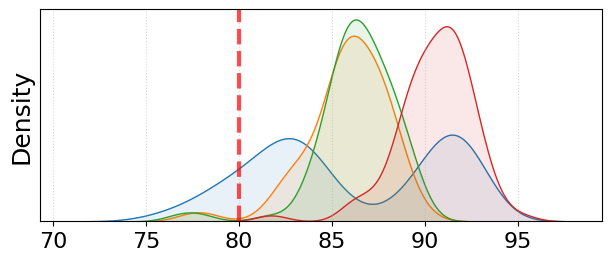

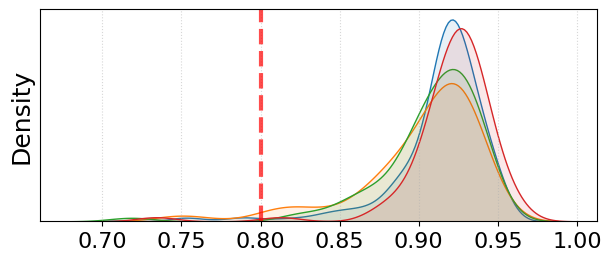

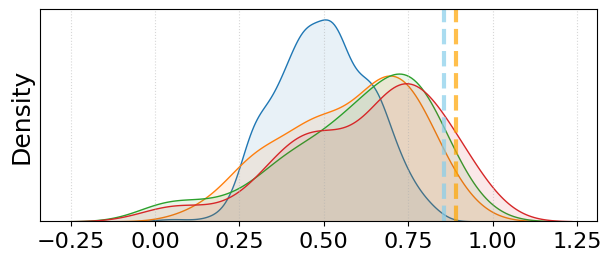

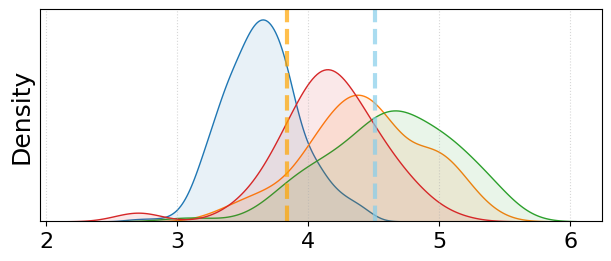

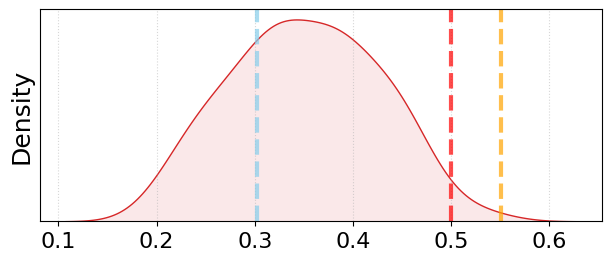

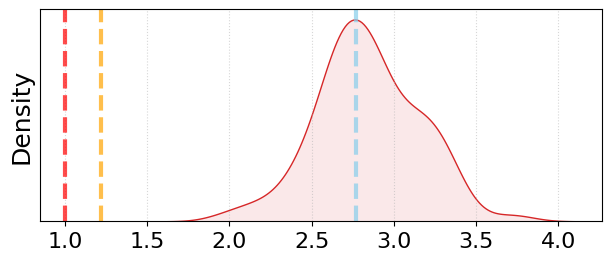

In [13]:
# pLDDT
plot_comparative_distributions([mev_df_replicate_1_esm, mev_df_replicate_1_fold, mev_df_replicate_1_cofold, mev_df_replicate_1_boltz], "pLDDT_mean", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[80], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# TM_score
plot_comparative_distributions([mev_df_replicate_1_esm, mev_df_replicate_1_fold, mev_df_replicate_1_cofold, mev_df_replicate_1_boltz], "TMscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.8], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['red'])

# Gnina cnn_score
plot_comparative_distributions([mev_df_replicate_1_esm, mev_df_replicate_1_fold, mev_df_replicate_1_cofold, mev_df_replicate_1_boltz], "Gnina_CNNscore", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.89089,0.855], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange', 'skyblue'])

# Gnina affinity score
plot_comparative_distributions([mev_df_replicate_1_esm, mev_df_replicate_1_fold, mev_df_replicate_1_cofold, mev_df_replicate_1_boltz], "Gnina_affinity", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[3.83604, 4.51], dist_colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'], line_colors=['orange', 'skyblue'])

# Boltz binary
plot_comparative_distributions([mev_df_replicate_1_boltz_native], "affinity_probability_binary", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[0.5,0.5506,0.302], dist_colors=['#D62728'], line_colors=['red', 'orange','skyblue'])

# Boltz affinity prob
plot_comparative_distributions([mev_df_replicate_1_boltz_native], "affinity_pred_value", tittle="", df_labels=None, figsize=(6, 2.5), show_legend=False, output_file=None, vertical_lines=[1,1.2175,2.77], dist_colors=['#D62728'], line_colors=['red', 'orange','skyblue'])

## Correlation Gnina - Boltz

I will make the comparison of boltz vs chai cofold

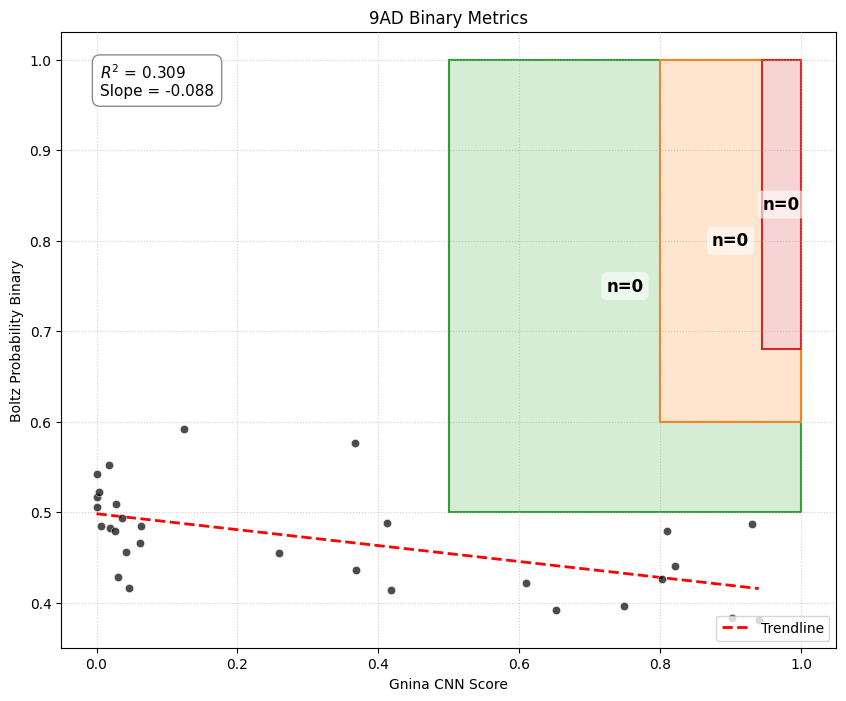

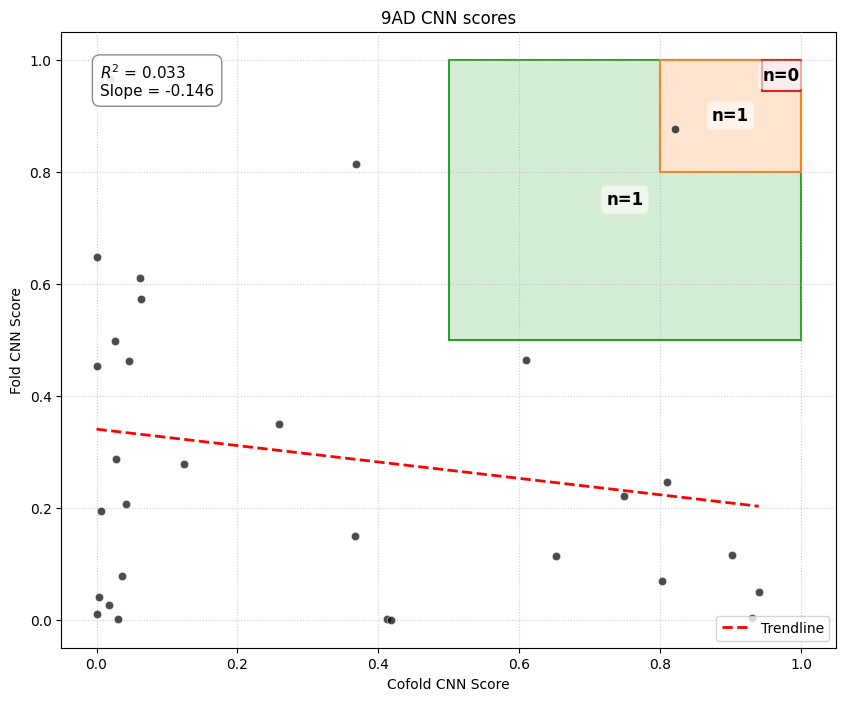

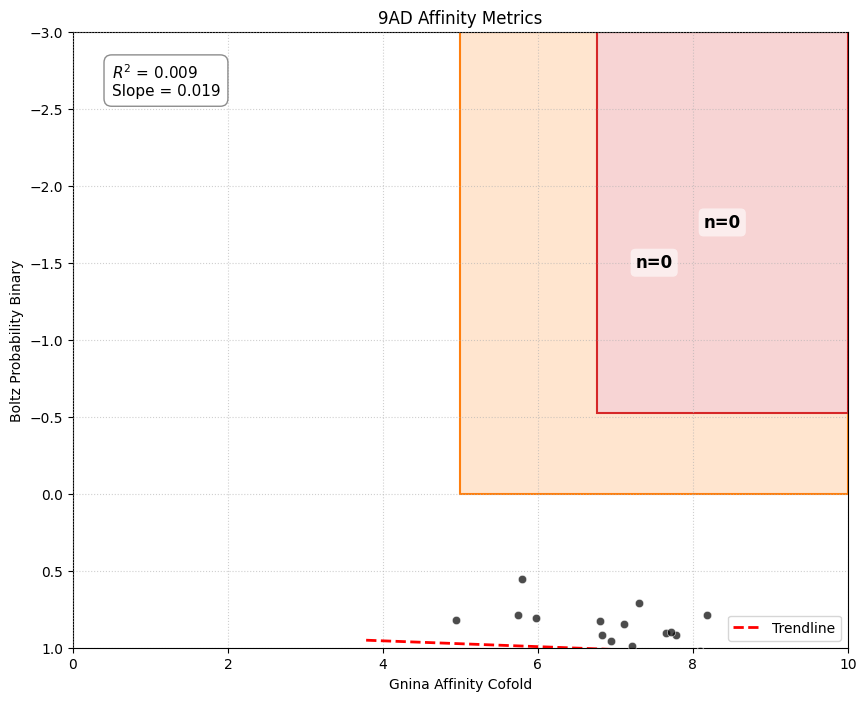

(0.01887608323918853, 0.009480890687978555)

In [9]:
### 9AD

### Binary metrics
plot_custom_scatter(x_data=tdc_df_replicate_1_cofold["Gnina_CNNscore"], y_data=tdc_df_replicate_1_boltz_native["affinity_probability_binary"], x_regions=[(0.5,1), (0.8,1), (0.94421,1)], y_regions=[(0.5,1), (0.6,1),(0.68,1)], region_colors=['#2CA02C','#FF7F0E', '#D62728'], title="9AD Binary Metrics", xlabel="Gnina CNN Score", ylabel="Boltz Probability Binary", xlim=None, ylim=None)

### Cofold CNN score vs Fold CNN score 
plot_custom_scatter(x_data=tdc_df_replicate_1_cofold["Gnina_CNNscore"], y_data=tdc_df_replicate_1_fold["Gnina_CNNscore"], x_regions=[(0.5,1), (0.8,1), (0.94421,1)], y_regions=[(0.5,1), (0.8,1), (0.94421,1)], region_colors=['#2CA02C','#FF7F0E', '#D62728'], title="9AD CNN scores", xlabel="Cofold CNN Score", ylabel="Fold CNN Score", xlim=None, ylim=None)

### GNina affinity cofold vs Boltz affinity
plot_custom_scatter(x_data=tdc_df_replicate_1_cofold["Gnina_affinity"], y_data=tdc_df_replicate_1_boltz_native["affinity_pred_value"], x_regions=[(5,10), (6.75738, 10)], y_regions=[(-3,0), (-3,-0.523)], region_colors=['#FF7F0E', '#D62728'], title="9AD Affinity Metrics", xlabel="Gnina Affinity Cofold", ylabel="Boltz Probability Binary", xlim=[0,10], ylim=[1,-3])



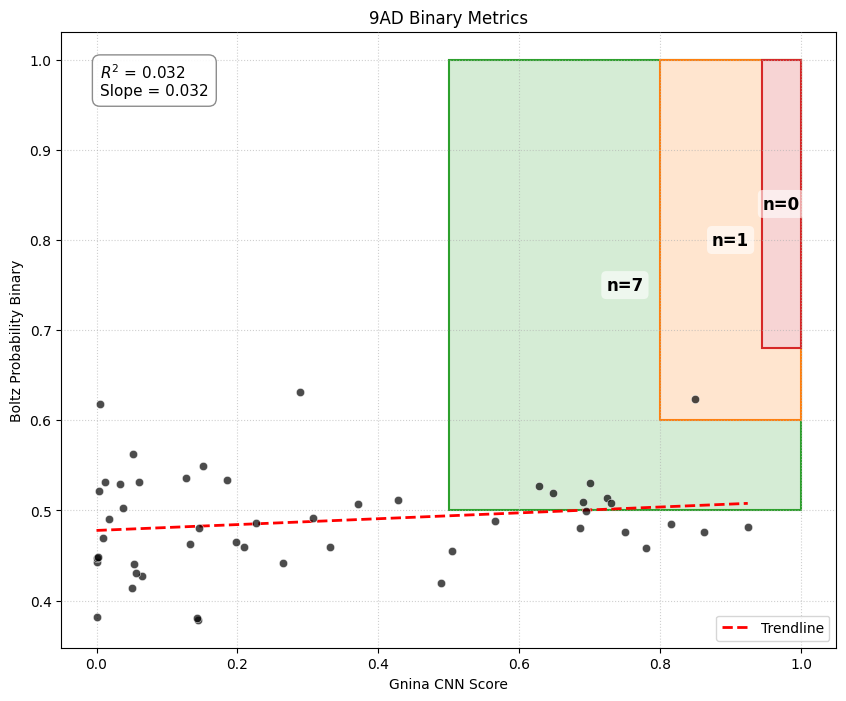

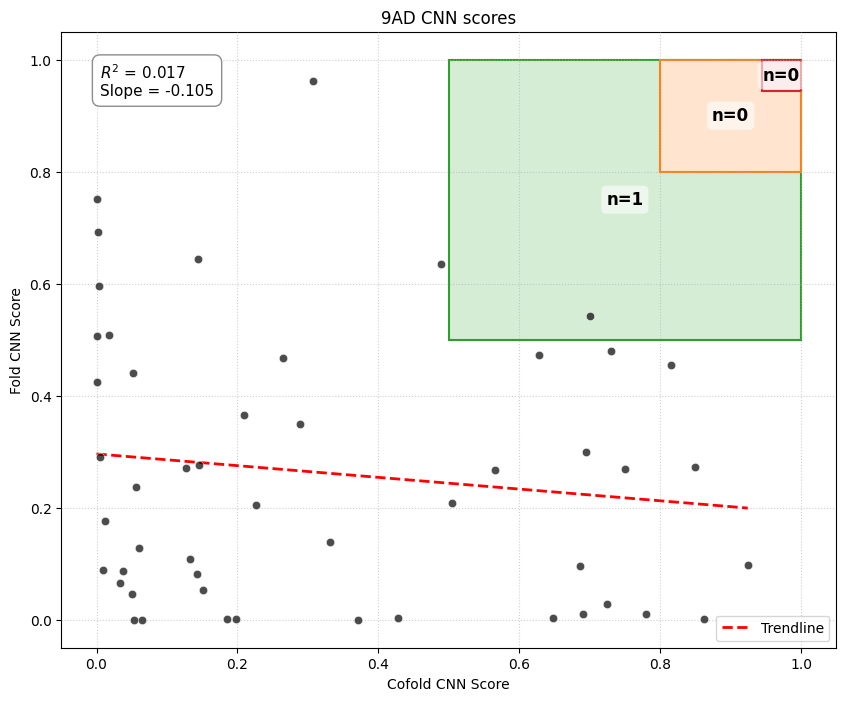

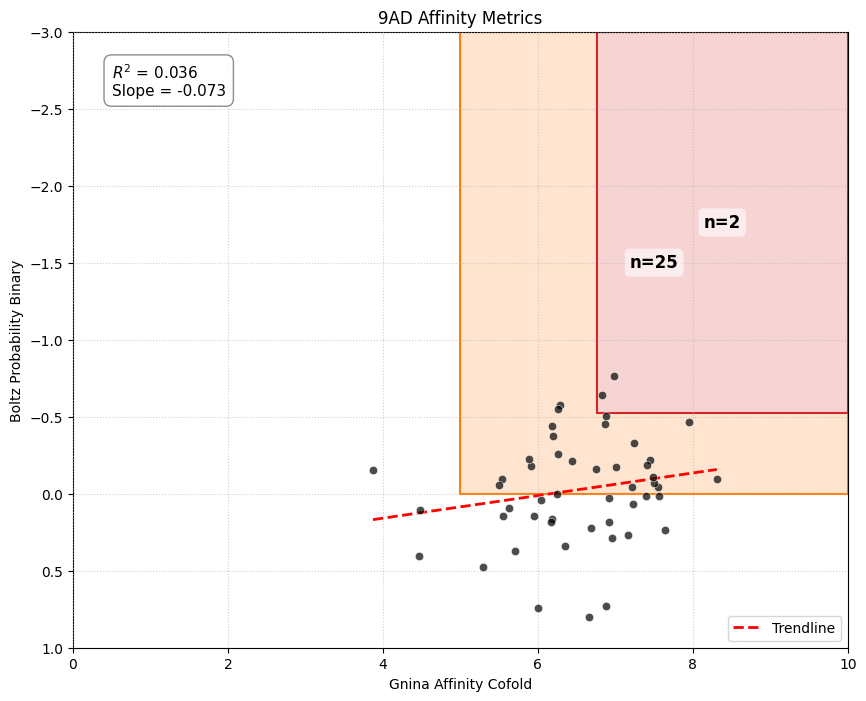

(-0.07344071328959045, 0.036494450846901484)

In [23]:
### 9AD

### Binary metrics
plot_custom_scatter(x_data=nad_df_replicate_1_cofold["Gnina_CNNscore"], y_data=nad_df_replicate_1_boltz_native["affinity_probability_binary"], x_regions=[(0.5,1), (0.8,1), (0.94421,1)], y_regions=[(0.5,1), (0.6,1),(0.68,1)], region_colors=['#2CA02C','#FF7F0E', '#D62728'], title="9AD Binary Metrics", xlabel="Gnina CNN Score", ylabel="Boltz Probability Binary", xlim=None, ylim=None)

### Cofold CNN score vs Fold CNN score 
plot_custom_scatter(x_data=nad_df_replicate_1_cofold["Gnina_CNNscore"], y_data=nad_df_replicate_1_fold["Gnina_CNNscore"], x_regions=[(0.5,1), (0.8,1), (0.94421,1)], y_regions=[(0.5,1), (0.8,1), (0.94421,1)], region_colors=['#2CA02C','#FF7F0E', '#D62728'], title="9AD CNN scores", xlabel="Cofold CNN Score", ylabel="Fold CNN Score", xlim=None, ylim=None)

### GNina affinity cofold vs Boltz affinity
plot_custom_scatter(x_data=nad_df_replicate_1_cofold["Gnina_affinity"], y_data=nad_df_replicate_1_boltz_native["affinity_pred_value"], x_regions=[(5,10), (6.75738, 10)], y_regions=[(-3,0), (-3,-0.523)], region_colors=['#FF7F0E', '#D62728'], title="9AD Affinity Metrics", xlabel="Gnina Affinity Cofold", ylabel="Boltz Probability Binary", xlim=[0,10], ylim=[1,-3])



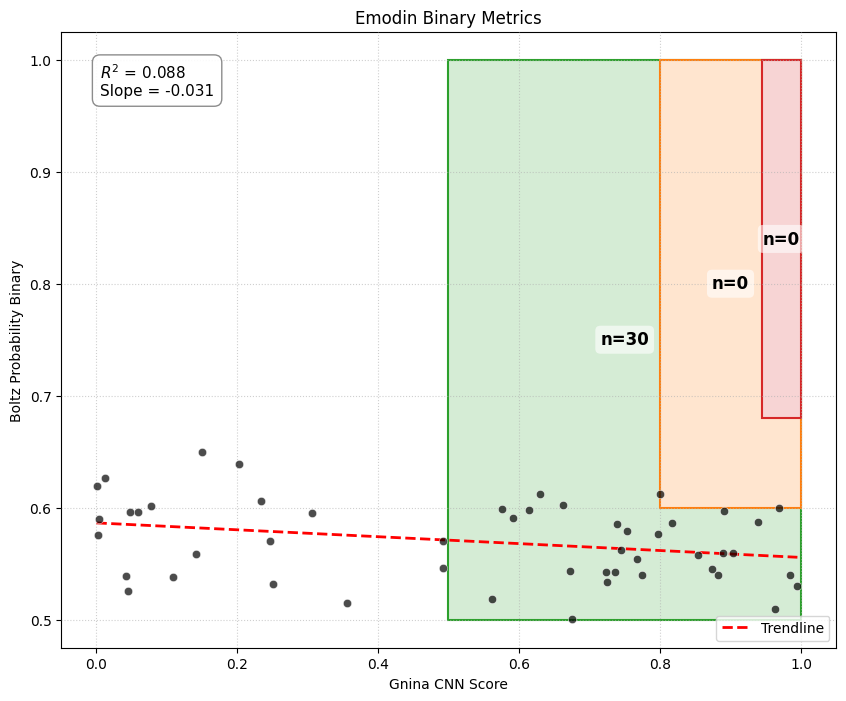

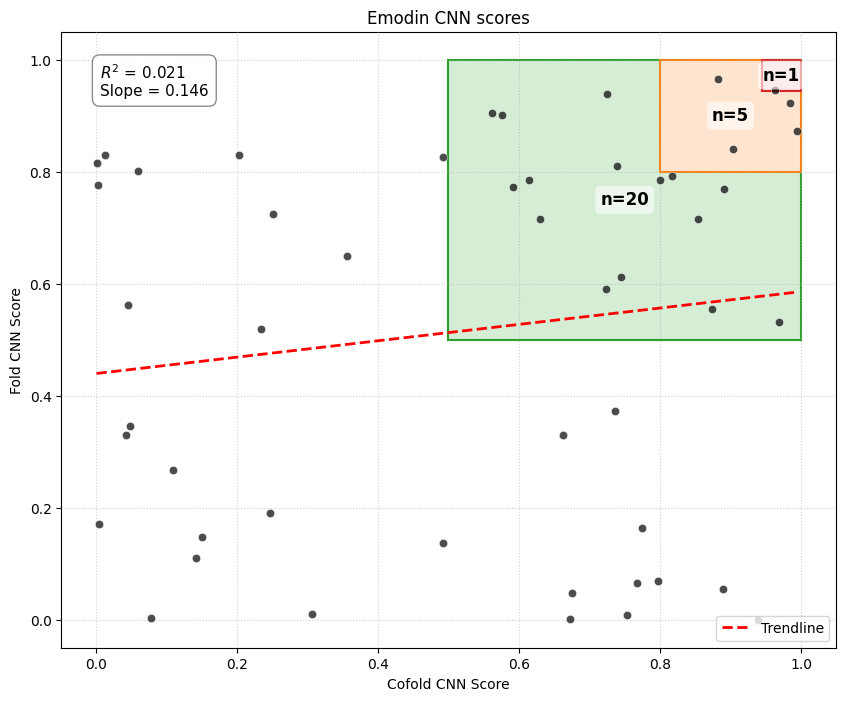

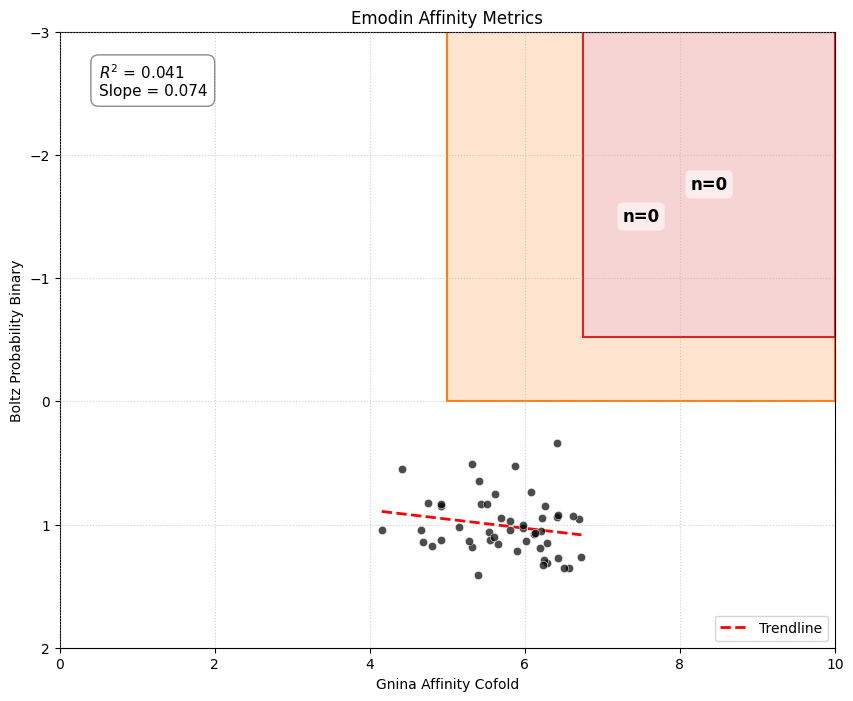

(0.07379781492800051, 0.040997597662157936)

In [11]:
### Emodin

### Binary metrics
plot_custom_scatter(x_data=emo_df_replicate_1_cofold["Gnina_CNNscore"], y_data=emo_df_replicate_1_boltz_native["affinity_probability_binary"], x_regions=[(0.5,1), (0.8,1), (0.94421,1)], y_regions=[(0.5,1), (0.6,1),(0.68,1)], region_colors=['#2CA02C','#FF7F0E', '#D62728'], title="Emodin Binary Metrics", xlabel="Gnina CNN Score", ylabel="Boltz Probability Binary", xlim=None, ylim=None)

### Cofold CNN score vs Fold CNN score 
plot_custom_scatter(x_data=emo_df_replicate_1_cofold["Gnina_CNNscore"], y_data=emo_df_replicate_1_fold["Gnina_CNNscore"], x_regions=[(0.5,1), (0.8,1), (0.94421,1)], y_regions=[(0.5,1), (0.8,1), (0.94421,1)], region_colors=['#2CA02C','#FF7F0E', '#D62728'], title="Emodin CNN scores", xlabel="Cofold CNN Score", ylabel="Fold CNN Score", xlim=None, ylim=None)

### GNina affinity cofold vs Boltz affinity
plot_custom_scatter(x_data=emo_df_replicate_1_cofold["Gnina_affinity"], y_data=emo_df_replicate_1_boltz_native["affinity_pred_value"], x_regions=[(5,10), (6.75738, 10)], y_regions=[(-3,0), (-3,-0.523)], region_colors=['#FF7F0E', '#D62728'], title="Emodin Affinity Metrics", xlabel="Gnina Affinity Cofold", ylabel="Boltz Probability Binary", xlim=[0,10], ylim=[2,-3])



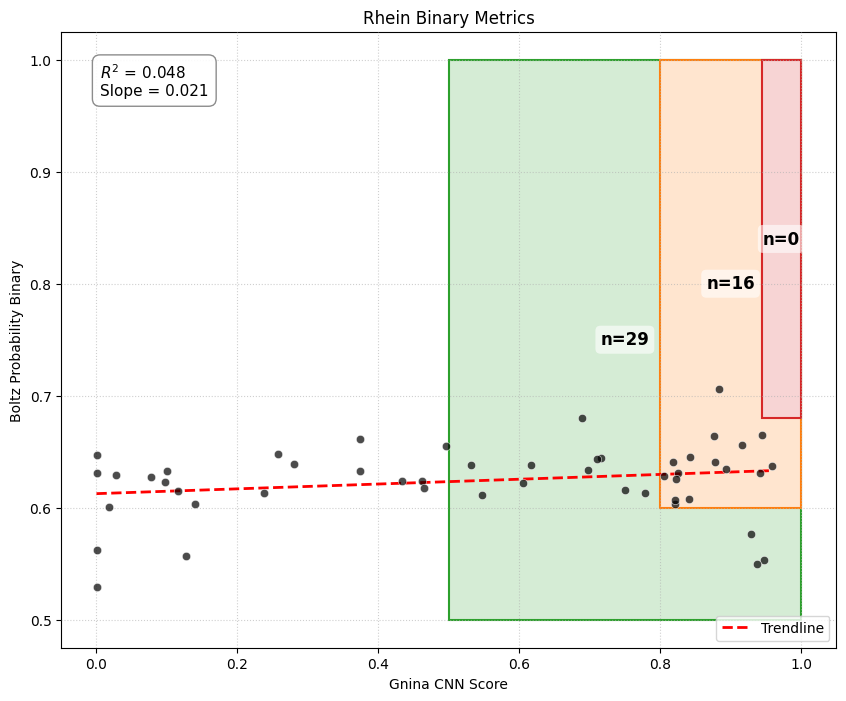

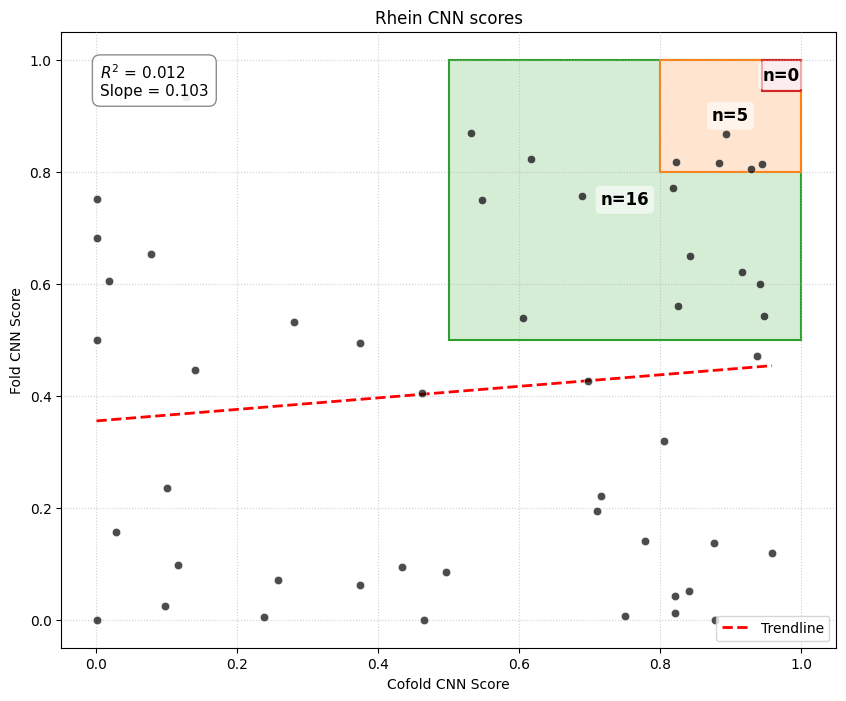

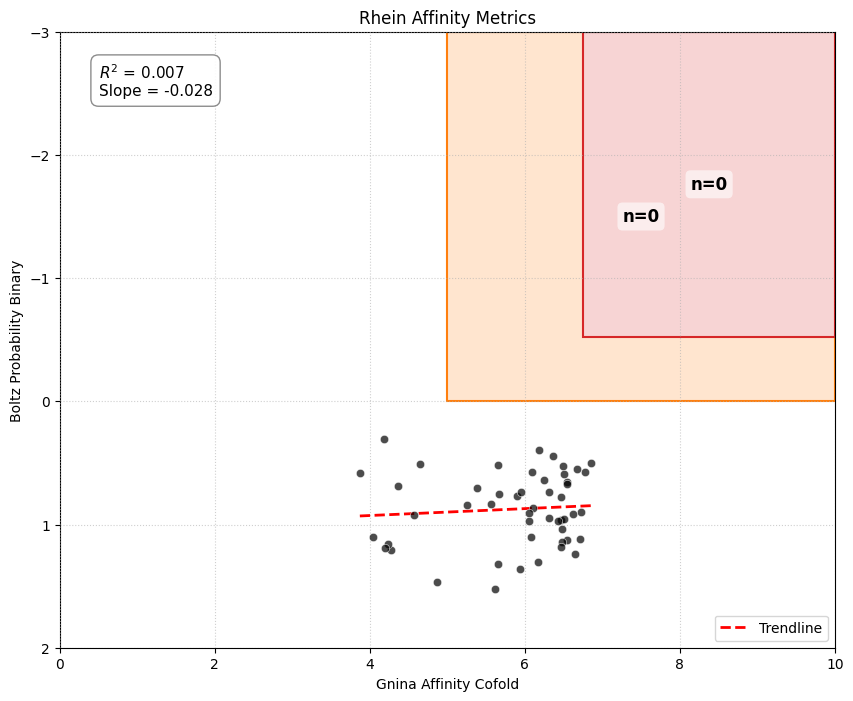

(-0.02799964618404726, 0.006689995284936151)

In [7]:
### Rhein

### Binary metrics
plot_custom_scatter(x_data=rhein_df_replicate_1_cofold["Gnina_CNNscore"], y_data=rhein_df_replicate_1_boltz_native["affinity_probability_binary"], x_regions=[(0.5,1), (0.8,1), (0.94421,1)], y_regions=[(0.5,1), (0.6,1),(0.68,1)], region_colors=['#2CA02C','#FF7F0E', '#D62728'], title="Rhein Binary Metrics", xlabel="Gnina CNN Score", ylabel="Boltz Probability Binary", xlim=None, ylim=None)

### Cofold CNN score vs Fold CNN score 
plot_custom_scatter(x_data=rhein_df_replicate_1_cofold["Gnina_CNNscore"], y_data=rhein_df_replicate_1_fold["Gnina_CNNscore"], x_regions=[(0.5,1), (0.8,1), (0.94421,1)], y_regions=[(0.5,1), (0.8,1), (0.94421,1)], region_colors=['#2CA02C','#FF7F0E', '#D62728'], title="Rhein CNN scores", xlabel="Cofold CNN Score", ylabel="Fold CNN Score", xlim=None, ylim=None)

### GNina affinity cofold vs Boltz affinity
plot_custom_scatter(x_data=rhein_df_replicate_1_cofold["Gnina_affinity"], y_data=rhein_df_replicate_1_boltz_native["affinity_pred_value"], x_regions=[(5,10), (6.75738, 10)], y_regions=[(-3,0), (-3,-0.523)], region_colors=['#FF7F0E', '#D62728'], title="Rhein Affinity Metrics", xlabel="Gnina Affinity Cofold", ylabel="Boltz Probability Binary", xlim=[0,10], ylim=[2,-3])



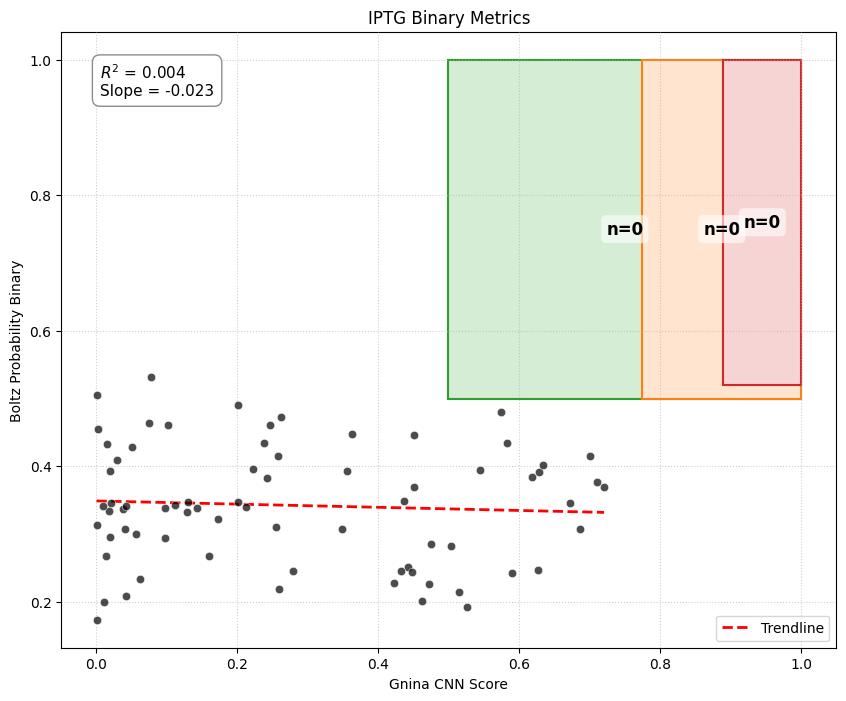

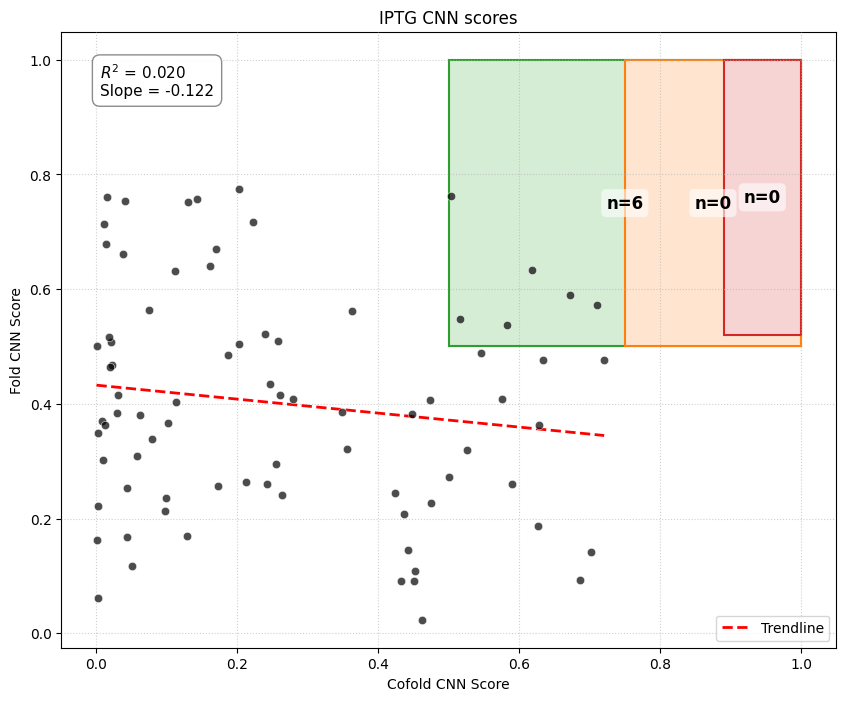

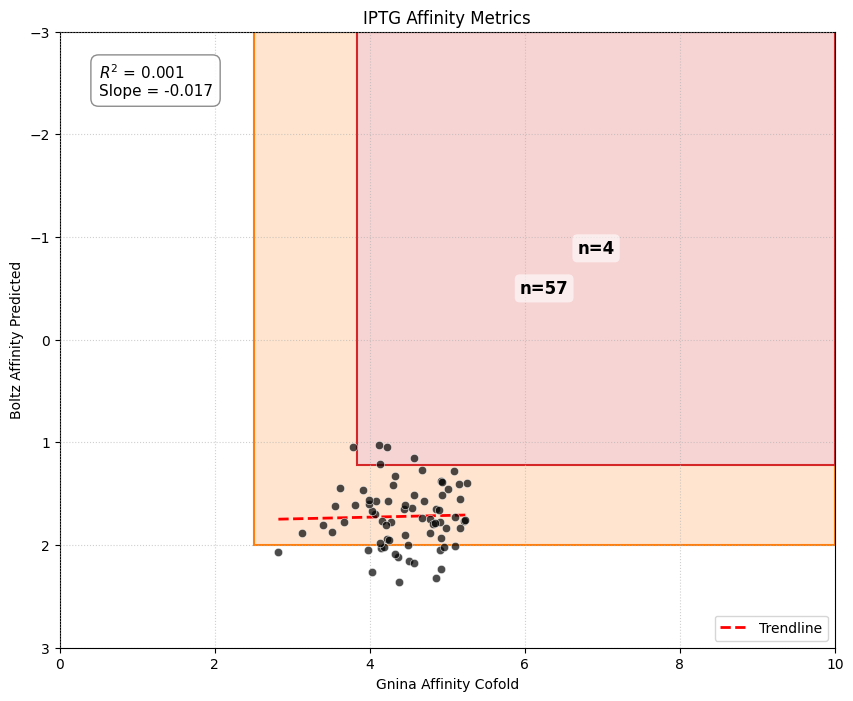

(-0.01673570219756652, 0.0008368546472514231)

In [13]:
### IPTG

# ---------------------------------------------------------
# 1. Binary metrics
# ---------------------------------------------------------
# 1. Find the exact rows that exist in both dataframes
idx_bin = ipt_df_replicate_1_cofold.index.intersection(ipt_df_replicate_1_boltz_native.index)

# 2. Plot using ONLY those overlapping rows
plot_custom_scatter(
    x_data=ipt_df_replicate_1_cofold.loc[idx_bin, "Gnina_CNNscore"], 
    y_data=ipt_df_replicate_1_boltz_native.loc[idx_bin, "affinity_probability_binary"], 
    x_regions=[(0.5,1), (0.775,1), (0.89,1)], 
    y_regions=[(0.5,1), (0.5,1),(0.5203,1)], 
    region_colors=['#2CA02C','#FF7F0E', '#D62728'], 
    title="IPTG Binary Metrics", 
    xlabel="Gnina CNN Score", 
    ylabel="Boltz Probability Binary", 
    xlim=None, 
    ylim=None
)

# ---------------------------------------------------------
# 2. Cofold CNN score vs Fold CNN score
# ---------------------------------------------------------
# Find common rows between cofold and fold
idx_cnn = ipt_df_replicate_1_cofold.index.intersection(ipt_df_replicate_1_fold.index)

plot_custom_scatter(
    x_data=ipt_df_replicate_1_cofold.loc[idx_cnn, "Gnina_CNNscore"], 
    y_data=ipt_df_replicate_1_fold.loc[idx_cnn, "Gnina_CNNscore"], 
    x_regions=[(0.5,1), (0.75,1), (0.89,1)], 
    y_regions=[(0.5,1), (0.5,1), (0.5203,1)], 
    region_colors=['#2CA02C','#FF7F0E', '#D62728'], 
    title="IPTG CNN scores", 
    xlabel="Cofold CNN Score", 
    ylabel="Fold CNN Score", 
    xlim=None, 
    ylim=None
)

# ---------------------------------------------------------
# 3. GNina affinity cofold vs Boltz affinity
# ---------------------------------------------------------
# Find common rows between cofold and boltz_native
idx_aff = ipt_df_replicate_1_cofold.index.intersection(ipt_df_replicate_1_boltz_native.index)

plot_custom_scatter(
    x_data=ipt_df_replicate_1_cofold.loc[idx_aff, "Gnina_affinity"], 
    y_data=ipt_df_replicate_1_boltz_native.loc[idx_aff, "affinity_pred_value"], 
    x_regions=[(2.5,10), (3.84, 10)], 
    y_regions=[(-3,2), (-3,1.22)], 
    region_colors=['#FF7F0E', '#D62728'], 
    title="IPTG Affinity Metrics", 
    xlabel="Gnina Affinity Cofold", 
    ylabel="Boltz Affinity Predicted", # Note: I updated this label from "Boltz Probability Binary" to reflect the actual y_data
    xlim=[0,10], 
    ylim=[3,-3]
)

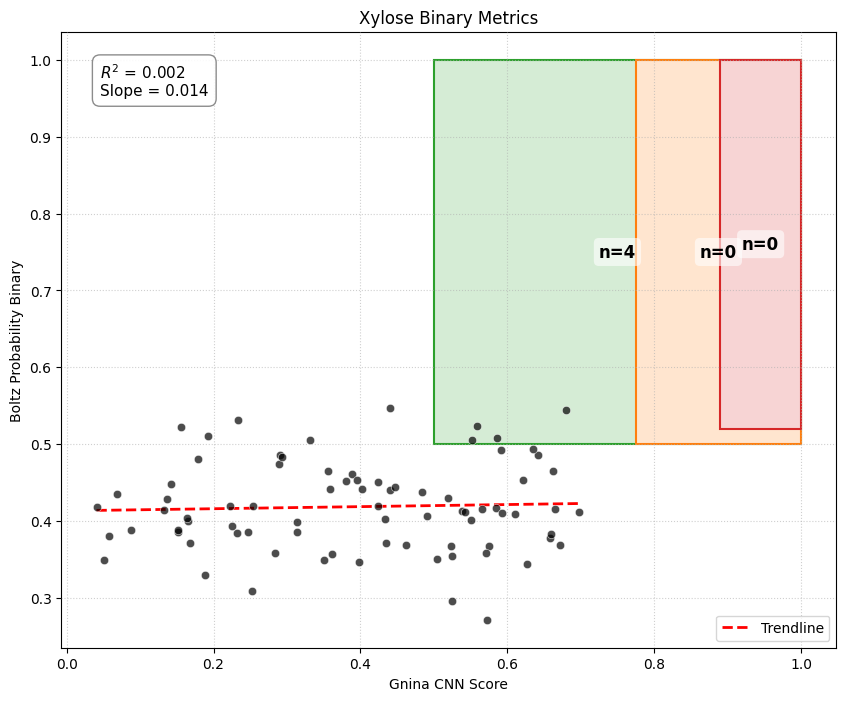

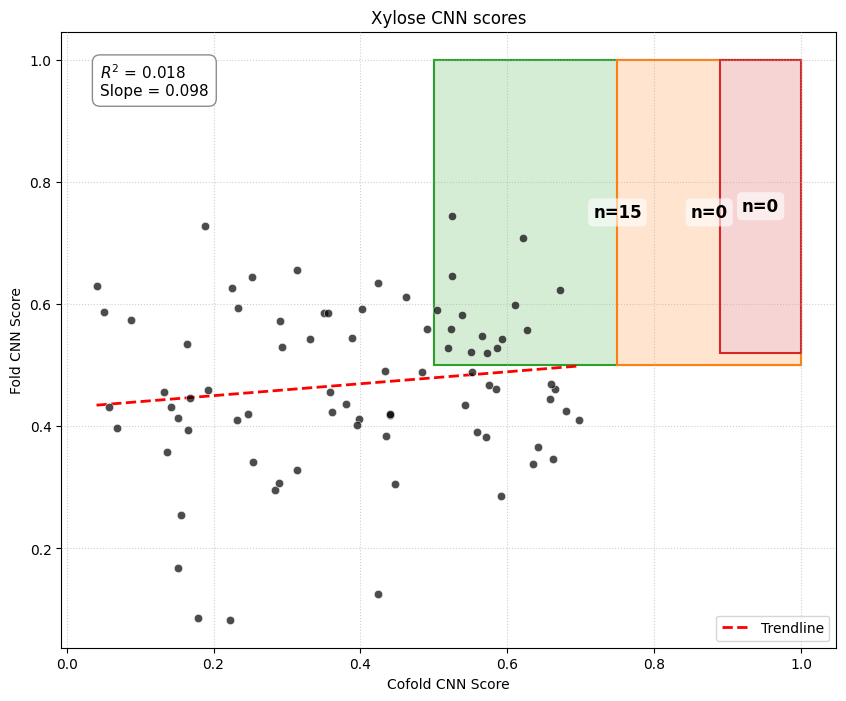

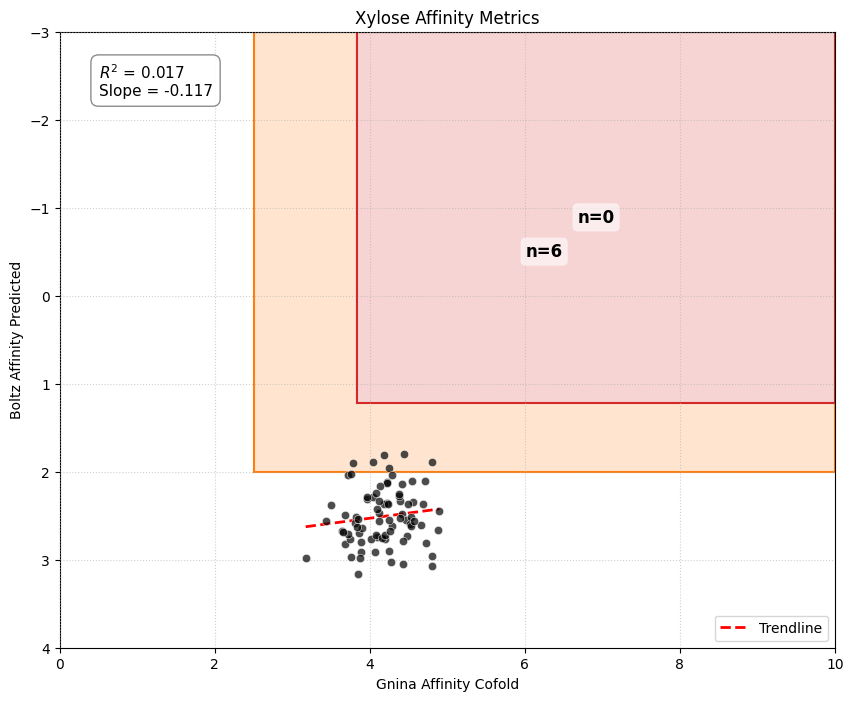

(-0.11699864231521703, 0.017132715962377237)

In [15]:
### Xylose

# ---------------------------------------------------------
# 1. Binary metrics
# ---------------------------------------------------------
# 1. Find the exact rows that exist in both dataframes
idx_bin = xyl_df_replicate_1_cofold.index.intersection(xyl_df_replicate_1_boltz_native.index)

# 2. Plot using ONLY those overlapping rows
plot_custom_scatter(
    x_data=xyl_df_replicate_1_cofold.loc[idx_bin, "Gnina_CNNscore"], 
    y_data=xyl_df_replicate_1_boltz_native.loc[idx_bin, "affinity_probability_binary"], 
    x_regions=[(0.5,1), (0.775,1), (0.89,1)], 
    y_regions=[(0.5,1), (0.5,1),(0.5203,1)], 
    region_colors=['#2CA02C','#FF7F0E', '#D62728'], 
    title="Xylose Binary Metrics", 
    xlabel="Gnina CNN Score", 
    ylabel="Boltz Probability Binary", 
    xlim=None, 
    ylim=None
)

# ---------------------------------------------------------
# 2. Cofold CNN score vs Fold CNN score
# ---------------------------------------------------------
# Find common rows between cofold and fold
idx_cnn = xyl_df_replicate_1_cofold.index.intersection(xyl_df_replicate_1_fold.index)

plot_custom_scatter(
    x_data=xyl_df_replicate_1_cofold.loc[idx_cnn, "Gnina_CNNscore"], 
    y_data=xyl_df_replicate_1_fold.loc[idx_cnn, "Gnina_CNNscore"], 
    x_regions=[(0.5,1), (0.75,1), (0.89,1)], 
    y_regions=[(0.5,1), (0.5,1), (0.5203,1)], 
    region_colors=['#2CA02C','#FF7F0E', '#D62728'], 
    title="Xylose CNN scores", 
    xlabel="Cofold CNN Score", 
    ylabel="Fold CNN Score", 
    xlim=None, 
    ylim=None
)

# ---------------------------------------------------------
# 3. GNina affinity cofold vs Boltz affinity
# ---------------------------------------------------------
# Find common rows between cofold and boltz_native
idx_aff = xyl_df_replicate_1_cofold.index.intersection(xyl_df_replicate_1_boltz_native.index)

plot_custom_scatter(
    x_data=xyl_df_replicate_1_cofold.loc[idx_aff, "Gnina_affinity"], 
    y_data=xyl_df_replicate_1_boltz_native.loc[idx_aff, "affinity_pred_value"], 
    x_regions=[(2.5,10), (3.84, 10)], 
    y_regions=[(-3,2), (-3,1.22)], 
    region_colors=['#FF7F0E', '#D62728'], 
    title="Xylose Affinity Metrics", 
    xlabel="Gnina Affinity Cofold", 
    ylabel="Boltz Affinity Predicted", # Note: I updated this label from "Boltz Probability Binary" to reflect the actual y_data
    xlim=[0,10], 
    ylim=[4,-3]
)

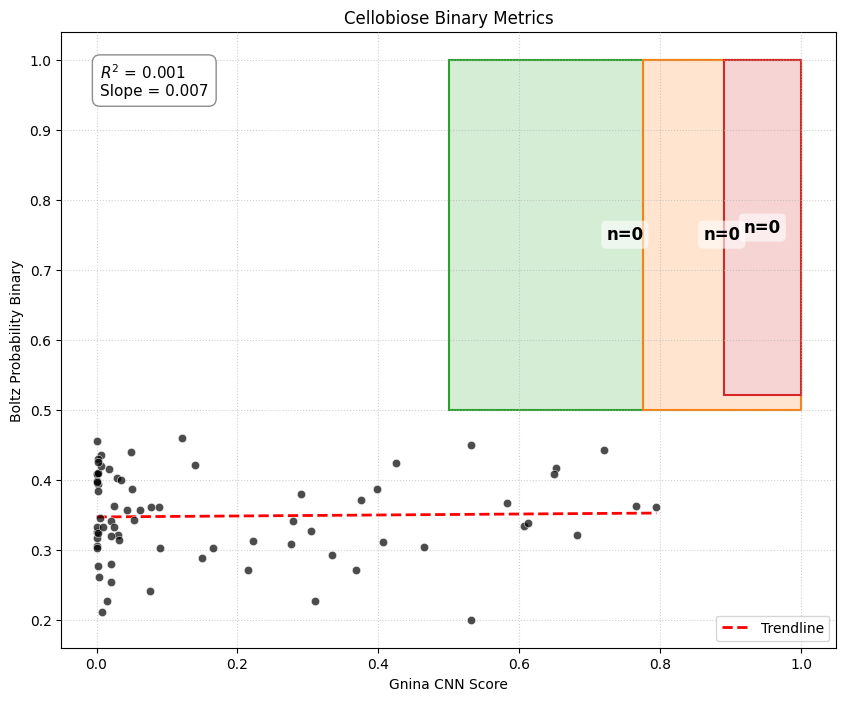

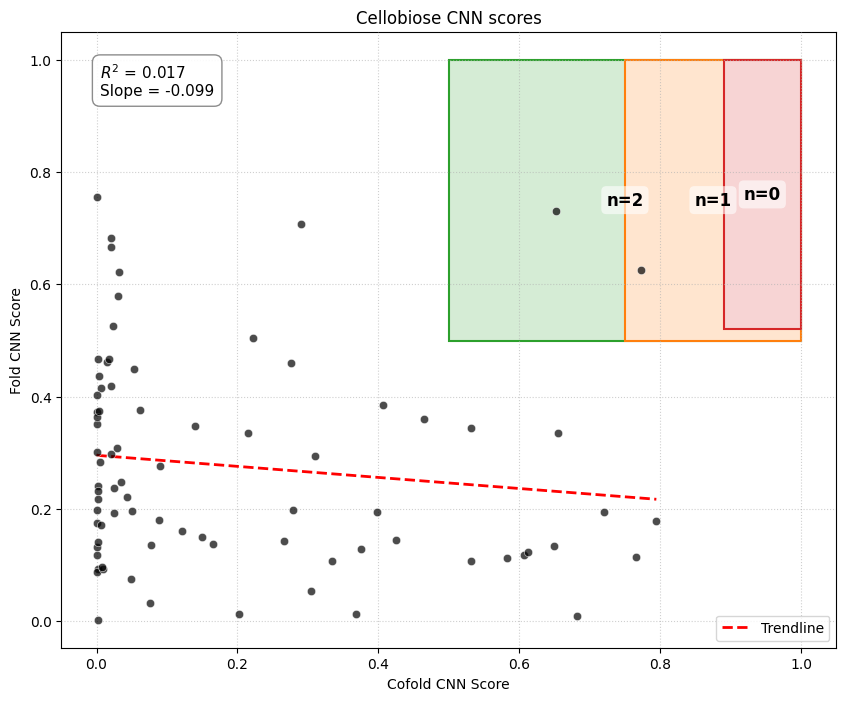

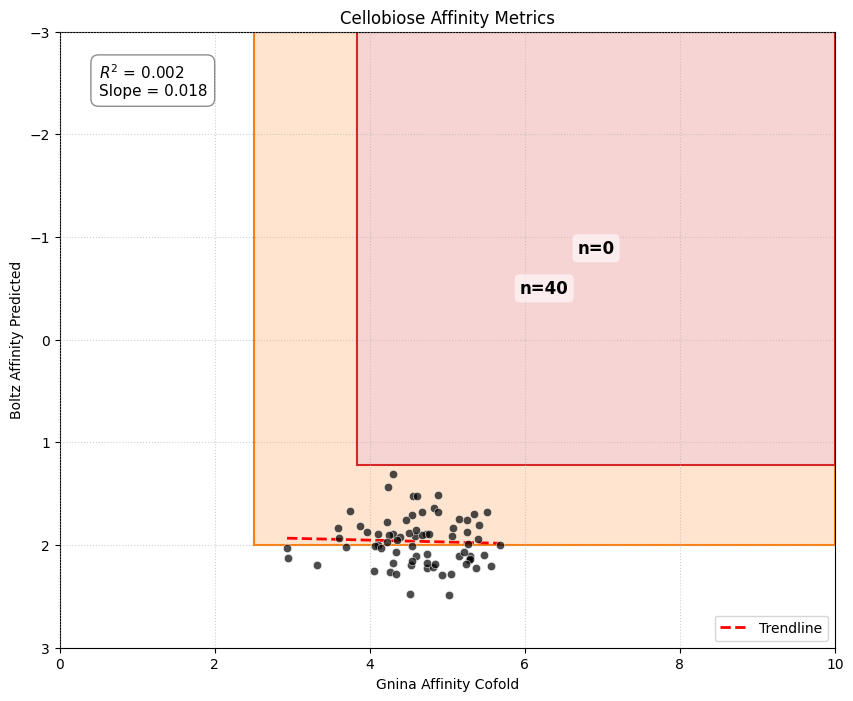

(0.018109256167101385, 0.002088731082718891)

In [16]:
### Cellobiose

# ---------------------------------------------------------
# 1. Binary metrics
# ---------------------------------------------------------
# 1. Find the exact rows that exist in both dataframes
idx_bin = cbs_df_replicate_1_cofold.index.intersection(cbs_df_replicate_1_boltz_native.index)

# 2. Plot using ONLY those overlapping rows
plot_custom_scatter(
    x_data=cbs_df_replicate_1_cofold.loc[idx_bin, "Gnina_CNNscore"], 
    y_data=cbs_df_replicate_1_boltz_native.loc[idx_bin, "affinity_probability_binary"], 
    x_regions=[(0.5,1), (0.775,1), (0.89,1)], 
    y_regions=[(0.5,1), (0.5,1),(0.5203,1)], 
    region_colors=['#2CA02C','#FF7F0E', '#D62728'], 
    title="Cellobiose Binary Metrics", 
    xlabel="Gnina CNN Score", 
    ylabel="Boltz Probability Binary", 
    xlim=None, 
    ylim=None
)

# ---------------------------------------------------------
# 2. Cofold CNN score vs Fold CNN score
# ---------------------------------------------------------
# Find common rows between cofold and fold
idx_cnn = cbs_df_replicate_1_cofold.index.intersection(cbs_df_replicate_1_fold.index)

plot_custom_scatter(
    x_data=cbs_df_replicate_1_cofold.loc[idx_cnn, "Gnina_CNNscore"], 
    y_data=cbs_df_replicate_1_fold.loc[idx_cnn, "Gnina_CNNscore"], 
    x_regions=[(0.5,1), (0.75,1), (0.89,1)], 
    y_regions=[(0.5,1), (0.5,1), (0.5203,1)], 
    region_colors=['#2CA02C','#FF7F0E', '#D62728'], 
    title="Cellobiose CNN scores", 
    xlabel="Cofold CNN Score", 
    ylabel="Fold CNN Score", 
    xlim=None, 
    ylim=None
)

# ---------------------------------------------------------
# 3. GNina affinity cofold vs Boltz affinity
# ---------------------------------------------------------
# Find common rows between cofold and boltz_native
idx_aff = cbs_df_replicate_1_cofold.index.intersection(cbs_df_replicate_1_boltz_native.index)

plot_custom_scatter(
    x_data=cbs_df_replicate_1_cofold.loc[idx_aff, "Gnina_affinity"], 
    y_data=cbs_df_replicate_1_boltz_native.loc[idx_aff, "affinity_pred_value"], 
    x_regions=[(2.5,10), (3.84, 10)], 
    y_regions=[(-3,2), (-3,1.22)], 
    region_colors=['#FF7F0E', '#D62728'], 
    title="Cellobiose Affinity Metrics", 
    xlabel="Gnina Affinity Cofold", 
    ylabel="Boltz Affinity Predicted", # Note: I updated this label from "Boltz Probability Binary" to reflect the actual y_data
    xlim=[0,10], 
    ylim=[3,-3]
)

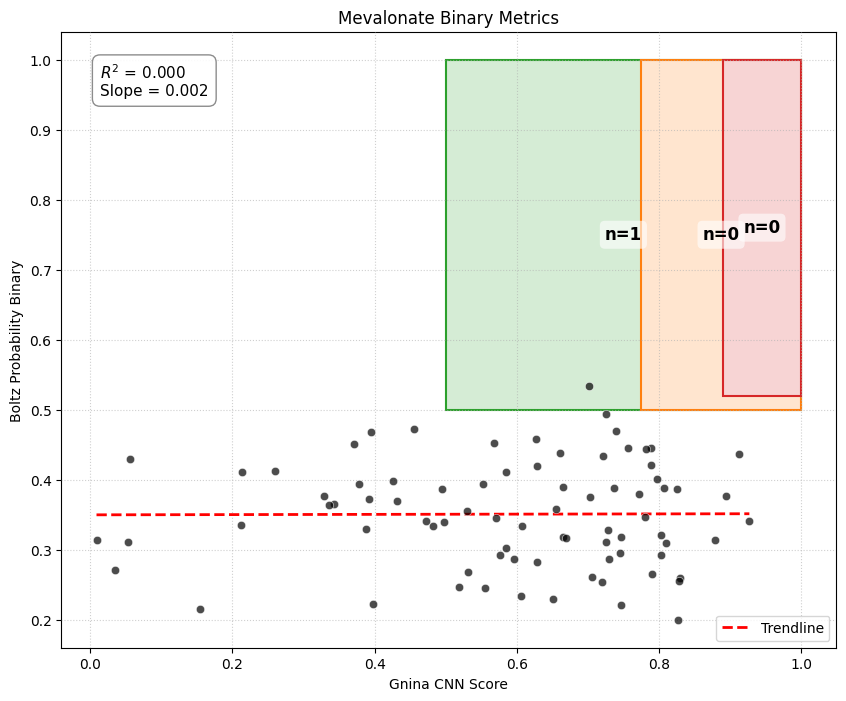

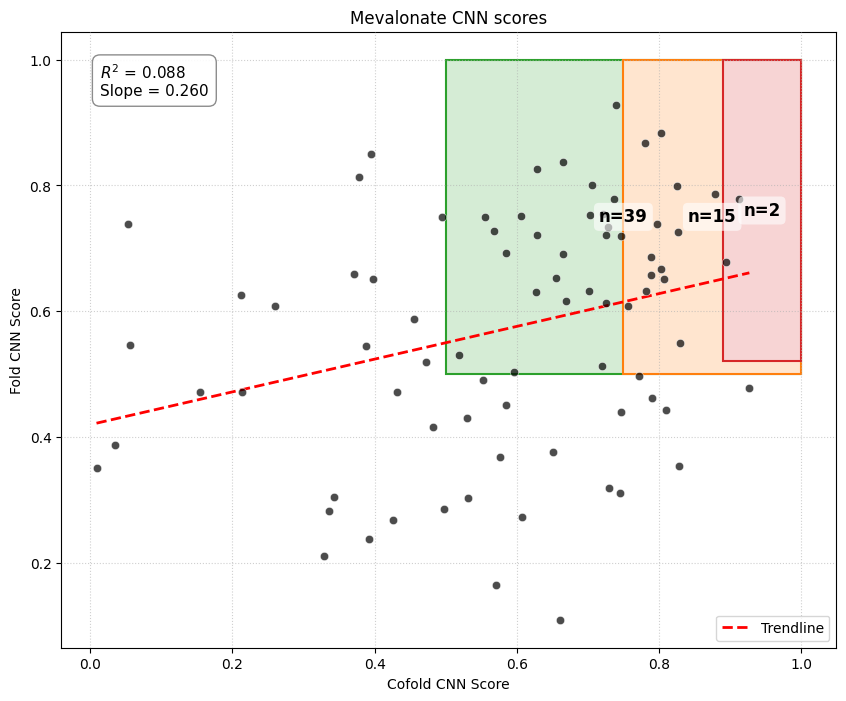

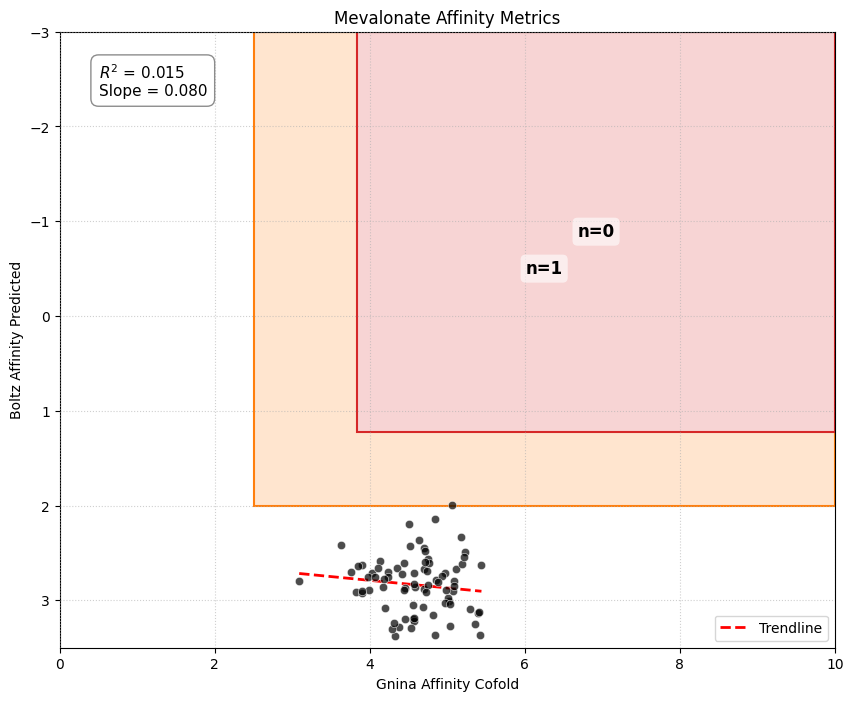

(0.07968268229191429, 0.015309626576988054)

In [18]:
### Mevalonate

# ---------------------------------------------------------
# 1. Binary metrics
# ---------------------------------------------------------
# 1. Find the exact rows that exist in both dataframes
idx_bin = mev_df_replicate_1_cofold.index.intersection(mev_df_replicate_1_boltz_native.index)

# 2. Plot using ONLY those overlapping rows
plot_custom_scatter(
    x_data=mev_df_replicate_1_cofold.loc[idx_bin, "Gnina_CNNscore"], 
    y_data=mev_df_replicate_1_boltz_native.loc[idx_bin, "affinity_probability_binary"], 
    x_regions=[(0.5,1), (0.775,1), (0.89,1)], 
    y_regions=[(0.5,1), (0.5,1),(0.5203,1)], 
    region_colors=['#2CA02C','#FF7F0E', '#D62728'], 
    title="Mevalonate Binary Metrics", 
    xlabel="Gnina CNN Score", 
    ylabel="Boltz Probability Binary", 
    xlim=None, 
    ylim=None
)

# ---------------------------------------------------------
# 2. Cofold CNN score vs Fold CNN score
# ---------------------------------------------------------
# Find common rows between cofold and fold
idx_cnn = mev_df_replicate_1_cofold.index.intersection(mev_df_replicate_1_fold.index)

plot_custom_scatter(
    x_data=mev_df_replicate_1_cofold.loc[idx_cnn, "Gnina_CNNscore"], 
    y_data=mev_df_replicate_1_fold.loc[idx_cnn, "Gnina_CNNscore"], 
    x_regions=[(0.5,1), (0.75,1), (0.89,1)], 
    y_regions=[(0.5,1), (0.5,1), (0.5203,1)], 
    region_colors=['#2CA02C','#FF7F0E', '#D62728'], 
    title="Mevalonate CNN scores", 
    xlabel="Cofold CNN Score", 
    ylabel="Fold CNN Score", 
    xlim=None, 
    ylim=None
)

# ---------------------------------------------------------
# 3. GNina affinity cofold vs Boltz affinity
# ---------------------------------------------------------
# Find common rows between cofold and boltz_native
idx_aff = mev_df_replicate_1_cofold.index.intersection(mev_df_replicate_1_boltz_native.index)

plot_custom_scatter(
    x_data=mev_df_replicate_1_cofold.loc[idx_aff, "Gnina_affinity"], 
    y_data=mev_df_replicate_1_boltz_native.loc[idx_aff, "affinity_pred_value"], 
    x_regions=[(2.5,10), (3.84, 10)], 
    y_regions=[(-3,2), (-3,1.22)], 
    region_colors=['#FF7F0E', '#D62728'], 
    title="Mevalonate Affinity Metrics", 
    xlabel="Gnina Affinity Cofold", 
    ylabel="Boltz Affinity Predicted", # Note: I updated this label from "Boltz Probability Binary" to reflect the actual y_data
    xlim=[0,10], 
    ylim=[3.5,-3]
)

## Data

## pLDDT

In [5]:
# TDC average pLDDT
print("TDC average pLDDT for ESM: ", ipt_df_replicate_1_esm["pLDDT_mean"].mean())
print("TDC average pLDDT for fold: ", ipt_df_replicate_1_fold["pLDDT_mean"].mean())
print("TDC average pLDDT for cofold: ", ipt_df_replicate_1_cofold["pLDDT_mean"].mean())
print("TDC average pLDDT for boltz: ", ipt_df_replicate_1_boltz["pLDDT_mean"].mean())

# TDC standard deviation of pLDDT
print("TDC standard deviation of pLDDT for ESM: ", ipt_df_replicate_1_esm["pLDDT_mean"].std())
print("TDC standard deviation of pLDDT for fold: ", ipt_df_replicate_1_fold["pLDDT_mean"].std())
print("TDC standard deviation of pLDDT for cofold: ", ipt_df_replicate_1_cofold["pLDDT_mean"].std())
print("TDC standard deviation of pLDDT for boltz: ", ipt_df_replicate_1_boltz["pLDDT_mean"].std())


TDC average pLDDT for ESM:  87.11794300554261
TDC average pLDDT for fold:  85.22725859855441
TDC average pLDDT for cofold:  86.3457597412665
TDC average pLDDT for boltz:  89.8981360824498
TDC standard deviation of pLDDT for ESM:  3.8232689481816178
TDC standard deviation of pLDDT for fold:  1.874796760534731
TDC standard deviation of pLDDT for cofold:  1.9465531512382048
TDC standard deviation of pLDDT for boltz:  2.1445183747419136


In [6]:
# 9AD average pLDDT
print("9AD average pLDDT for ESM: ", nad_df_replicate_1_esm["pLDDT_mean"].mean())
print("9AD average pLDDT for fold: ", nad_df_replicate_1_fold["pLDDT_mean"].mean())
print("9AD average pLDDT for cofold: ", nad_df_replicate_1_cofold["pLDDT_mean"].mean())
print("9AD average pLDDT for boltz: ", nad_df_replicate_1_boltz["pLDDT_mean"].mean())

# 9AD standard deviation of pLDDT
print("9AD standard deviation of pLDDT for ESM: ", nad_df_replicate_1_esm["pLDDT_mean"].std())
print("9AD standard deviation of pLDDT for fold: ", nad_df_replicate_1_fold["pLDDT_mean"].std())
print("9AD standard deviation of pLDDT for cofold: ", nad_df_replicate_1_cofold["pLDDT_mean"].std())
print("9AD standard deviation of pLDDT for boltz: ", nad_df_replicate_1_boltz["pLDDT_mean"].std())

9AD average pLDDT for ESM:  71.80558443880008
9AD average pLDDT for fold:  77.29758311069295
9AD average pLDDT for cofold:  78.6133343743414
9AD average pLDDT for boltz:  86.9424855225488
9AD standard deviation of pLDDT for ESM:  7.673571013233141
9AD standard deviation of pLDDT for fold:  3.9365081044566392
9AD standard deviation of pLDDT for cofold:  4.3482439779183135
9AD standard deviation of pLDDT for boltz:  3.7971771782237083


In [7]:
# Emodin average pLDDT
print("Emodin average pLDDT for ESM: ", emo_df_replicate_1_esm["pLDDT_mean"].mean())
print("Emodin average pLDDT for fold: ", emo_df_replicate_1_fold["pLDDT_mean"].mean())
print("Emodin average pLDDT for cofold: ", emo_df_replicate_1_cofold["pLDDT_mean"].mean())
print("Emodin average pLDDT for boltz: ", emo_df_replicate_1_boltz["pLDDT_mean"].mean())

# Emodin standard deviation of pLDDT
print("Emodin standard deviation of pLDDT for ESM: ", emo_df_replicate_1_esm["pLDDT_mean"].std())
print("Emodin standard deviation of pLDDT for fold: ", emo_df_replicate_1_fold["pLDDT_mean"].std())
print("Emodin standard deviation of pLDDT for cofold: ", emo_df_replicate_1_cofold["pLDDT_mean"].std())
print("Emodin standard deviation of pLDDT for boltz: ", emo_df_replicate_1_boltz["pLDDT_mean"].std())

Emodin average pLDDT for ESM:  71.04277533936573
Emodin average pLDDT for fold:  81.16134430475523
Emodin average pLDDT for cofold:  82.36413688469197
Emodin average pLDDT for boltz:  87.6957079534864
Emodin standard deviation of pLDDT for ESM:  7.303378612889011
Emodin standard deviation of pLDDT for fold:  2.636532336143523
Emodin standard deviation of pLDDT for cofold:  2.820802601885678
Emodin standard deviation of pLDDT for boltz:  3.490219969821331


In [8]:
# Rhein average pLDDT
print("Rhein average pLDDT for ESM: ", rhein_df_replicate_1_esm["pLDDT_mean"].mean())
print("Rhein average pLDDT for fold: ", rhein_df_replicate_1_fold["pLDDT_mean"].mean())
print("Rhein average pLDDT for cofold: ", rhein_df_replicate_1_cofold["pLDDT_mean"].mean())
print("Rhein average pLDDT for boltz: ", rhein_df_replicate_1_boltz["pLDDT_mean"].mean())

# Rhein standard deviation of pLDDT
print("Rhein standard deviation of pLDDT for ESM: ", rhein_df_replicate_1_esm["pLDDT_mean"].std())
print("Rhein standard deviation of pLDDT for fold: ", rhein_df_replicate_1_fold["pLDDT_mean"].std())
print("Rhein standard deviation of pLDDT for cofold: ", rhein_df_replicate_1_cofold["pLDDT_mean"].std())
print("Rhein standard deviation of pLDDT for boltz: ", rhein_df_replicate_1_boltz["pLDDT_mean"].std())

Rhein average pLDDT for ESM:  76.2661262911673
Rhein average pLDDT for fold:  83.32555201971387
Rhein average pLDDT for cofold:  84.24048704648003
Rhein average pLDDT for boltz:  88.98705019349977
Rhein standard deviation of pLDDT for ESM:  5.988989886050687
Rhein standard deviation of pLDDT for fold:  3.2428101251104176
Rhein standard deviation of pLDDT for cofold:  3.6802481126082354
Rhein standard deviation of pLDDT for boltz:  3.4999363722286936


In [14]:
# IPTG average pLDDT
print("IPTG average pLDDT for ESM: ", ipt_df_replicate_1_esm["pLDDT_mean"].mean())
print("IPTG average pLDDT for fold: ", ipt_df_replicate_1_fold["pLDDT_mean"].mean())
print("IPTG average pLDDT for cofold: ", ipt_df_replicate_1_cofold["pLDDT_mean"].mean())
print("IPTG average pLDDT for boltz: ", ipt_df_replicate_1_boltz["pLDDT_mean"].mean())

# IPTG standard deviation of pLDDT
print("IPTG standard deviation of pLDDT for ESM: ", ipt_df_replicate_1_esm["pLDDT_mean"].std())
print("IPTG standard deviation of pLDDT for fold: ", ipt_df_replicate_1_fold["pLDDT_mean"].std())
print("IPTG standard deviation of pLDDT for cofold: ", ipt_df_replicate_1_cofold["pLDDT_mean"].std())
print("IPTG standard deviation of pLDDT for boltz: ", ipt_df_replicate_1_boltz["pLDDT_mean"].std())

IPTG average pLDDT for ESM:  87.11794300554261
IPTG average pLDDT for fold:  85.22725859855441
IPTG average pLDDT for cofold:  86.3457597412665
IPTG average pLDDT for boltz:  89.8981360824498
IPTG standard deviation of pLDDT for ESM:  3.8232689481816178
IPTG standard deviation of pLDDT for fold:  1.874796760534731
IPTG standard deviation of pLDDT for cofold:  1.9465531512382048
IPTG standard deviation of pLDDT for boltz:  2.1445183747419136


In [4]:
# Xylose average pLDDT
print("Xylose average pLDDT for ESM: ", xyl_df_replicate_1_esm["pLDDT_mean"].mean())
print("Xylose average pLDDT for fold: ", xyl_df_replicate_1_fold["pLDDT_mean"].mean())
print("Xylose average pLDDT for cofold: ", xyl_df_replicate_1_cofold["pLDDT_mean"].mean())
print("Xylose average pLDDT for boltz: ", xyl_df_replicate_1_boltz["pLDDT_mean"].mean())

# Xylose standard deviation of pLDDT
print("Xylose standard deviation of pLDDT for ESM: ", xyl_df_replicate_1_esm["pLDDT_mean"].std())
print("Xylose standard deviation of pLDDT for fold: ", xyl_df_replicate_1_fold["pLDDT_mean"].std())
print("Xylose standard deviation of pLDDT for cofold: ", xyl_df_replicate_1_cofold["pLDDT_mean"].std())
print("Xylose standard deviation of pLDDT for boltz: ", xyl_df_replicate_1_boltz["pLDDT_mean"].std())

Xylose average pLDDT for ESM:  85.41323003713008
Xylose average pLDDT for fold:  84.86052103664542
Xylose average pLDDT for cofold:  85.42946619972443
Xylose average pLDDT for boltz:  89.19518784140665
Xylose standard deviation of pLDDT for ESM:  4.0418723987983185
Xylose standard deviation of pLDDT for fold:  1.8439190599267428
Xylose standard deviation of pLDDT for cofold:  1.9435259408186507
Xylose standard deviation of pLDDT for boltz:  2.5913841116535816


In [5]:
# Cellobiose average pLDDT
print("Cellobiose average pLDDT for ESM: ", cbs_df_replicate_1_esm["pLDDT_mean"].mean())
print("Cellobiose average pLDDT for fold: ", cbs_df_replicate_1_fold["pLDDT_mean"].mean())
print("Cellobiose average pLDDT for cofold: ", cbs_df_replicate_1_cofold["pLDDT_mean"].mean())
print("Cellobiose average pLDDT for boltz: ", cbs_df_replicate_1_boltz["pLDDT_mean"].mean())

# Cellobiose standard deviation of pLDDT
print("Cellobiose standard deviation of pLDDT for ESM: ", cbs_df_replicate_1_esm["pLDDT_mean"].std())
print("Cellobiose standard deviation of pLDDT for fold: ", cbs_df_replicate_1_fold["pLDDT_mean"].std())
print("Cellobiose standard deviation of pLDDT for cofold: ", cbs_df_replicate_1_cofold["pLDDT_mean"].std())
print("Cellobiose standard deviation of pLDDT for boltz: ", cbs_df_replicate_1_boltz["pLDDT_mean"].std())

Cellobiose average pLDDT for ESM:  85.322452956339
Cellobiose average pLDDT for fold:  86.40366176299656
Cellobiose average pLDDT for cofold:  87.44739134482383
Cellobiose average pLDDT for boltz:  90.52524076145535
Cellobiose standard deviation of pLDDT for ESM:  4.949857993677616
Cellobiose standard deviation of pLDDT for fold:  1.7438679521936613
Cellobiose standard deviation of pLDDT for cofold:  1.7753391050381158
Cellobiose standard deviation of pLDDT for boltz:  2.3760199682797167


In [6]:
# mevalonate average pLDDT
print("Mevalonate average pLDDT for ESM: ", mev_df_replicate_1_esm["pLDDT_mean"].mean())
print("Mevalonate average pLDDT for fold: ", mev_df_replicate_1_fold["pLDDT_mean"].mean())
print("Mevalonate average pLDDT for cofold: ", mev_df_replicate_1_cofold["pLDDT_mean"].mean())
print("Mevalonate average pLDDT for boltz: ", mev_df_replicate_1_boltz["pLDDT_mean"].mean())

# Mevalonate standard deviation of pLDDT
print("Mevalonate standard deviation of pLDDT for ESM: ", mev_df_replicate_1_esm["pLDDT_mean"].std())
print("Mevalonate standard deviation of pLDDT for fold: ", mev_df_replicate_1_fold["pLDDT_mean"].std())
print("Mevalonate standard deviation of pLDDT for cofold: ", mev_df_replicate_1_cofold["pLDDT_mean"].std())
print("Mevalonate standard deviation of pLDDT for boltz: ", mev_df_replicate_1_boltz["pLDDT_mean"].std())

Mevalonate average pLDDT for ESM:  85.8127037991041
Mevalonate average pLDDT for fold:  85.82261980309111
Mevalonate average pLDDT for cofold:  86.31745842805937
Mevalonate average pLDDT for boltz:  90.51390988104941
Mevalonate standard deviation of pLDDT for ESM:  5.061072598206537
Mevalonate standard deviation of pLDDT for fold:  2.20081656072329
Mevalonate standard deviation of pLDDT for cofold:  2.1286384796312543
Mevalonate standard deviation of pLDDT for boltz:  2.032563981177439


## TMscore

In [9]:
# TDC average TMscore
print("TDC average TMscore for ESM: ", ipt_df_replicate_1_esm["TMscore"].mean())
print("TDC average TMscore for fold: ", ipt_df_replicate_1_fold["TMscore"].mean())
print("TDC average TMscore for cofold: ", ipt_df_replicate_1_cofold["TMscore"].mean())
print("TDC average TMscore for boltz: ", ipt_df_replicate_1_boltz["TMscore"].mean())

# TDC standard deviation of TMscore
print("TDC standard deviation of TMscore for ESM: ", ipt_df_replicate_1_esm["TMscore"].std())
print("TDC standard deviation of TMscore for fold: ", ipt_df_replicate_1_fold["TMscore"].std())
print("TDC standard deviation of TMscore for cofold: ", ipt_df_replicate_1_cofold["TMscore"].std())
print("TDC standard deviation of TMscore for boltz: ", ipt_df_replicate_1_boltz["TMscore"].std())


TDC average TMscore for ESM:  0.9098764829873295
TDC average TMscore for fold:  0.8965768741079829
TDC average TMscore for cofold:  0.90315038585731
TDC average TMscore for boltz:  0.9155543334462894
TDC standard deviation of TMscore for ESM:  0.02752244083741228
TDC standard deviation of TMscore for fold:  0.036561736169797014
TDC standard deviation of TMscore for cofold:  0.03379161149197223
TDC standard deviation of TMscore for boltz:  0.021466293541991113


In [11]:
# 9AD average TMscore

print("9AD average TMscore for ESM: ", nad_df_replicate_1_esm["TMscore"].mean())
print("9AD average TMscore for fold: ", nad_df_replicate_1_fold["TMscore"].mean())
print("9AD average TMscore for cofold: ", nad_df_replicate_1_cofold["TMscore"].mean())
print("9AD average TMscore for boltz: ", nad_df_replicate_1_boltz["TMscore"].mean())

# 9AD standard deviation of TMscore
print("9AD standard deviation of TMscore for ESM: ", nad_df_replicate_1_esm["TMscore"].std())
print("9AD standard deviation of TMscore for fold: ", nad_df_replicate_1_fold["TMscore"].std())
print("9AD standard deviation of TMscore for cofold: ", nad_df_replicate_1_cofold["TMscore"].std())
print("9AD standard deviation of TMscore for boltz: ", nad_df_replicate_1_boltz["TMscore"].std())

9AD average TMscore for ESM:  0.7692166585366909
9AD average TMscore for fold:  0.7560664106248766
9AD average TMscore for cofold:  0.7470820992708893
9AD average TMscore for boltz:  0.8051739323760431
9AD standard deviation of TMscore for ESM:  0.09074515622067693
9AD standard deviation of TMscore for fold:  0.07606779663892285
9AD standard deviation of TMscore for cofold:  0.07990614246567974
9AD standard deviation of TMscore for boltz:  0.03532778089276736


In [12]:
# Emodin average TMscore
print("Emodin average TMscore for ESM: ", emo_df_replicate_1_esm["TMscore"].mean())
print("Emodin average TMscore for fold: ", emo_df_replicate_1_fold["TMscore"].mean())
print("Emodin average TMscore for cofold: ", emo_df_replicate_1_cofold["TMscore"].mean())
print("Emodin average TMscore for boltz: ", emo_df_replicate_1_boltz["TMscore"].mean())

# Emodin standard deviation of TMscore
print("Emodin standard deviation of TMscore for ESM: ", emo_df_replicate_1_esm["TMscore"].std())
print("Emodin standard deviation of TMscore for fold: ", emo_df_replicate_1_fold["TMscore"].std())
print("Emodin standard deviation of TMscore for cofold: ", emo_df_replicate_1_cofold["TMscore"].std())
print("Emodin standard deviation of TMscore for boltz: ", emo_df_replicate_1_boltz["TMscore"].std())

Emodin average TMscore for ESM:  0.7830129473084448
Emodin average TMscore for fold:  0.8210142742360352
Emodin average TMscore for cofold:  0.821349558558165
Emodin average TMscore for boltz:  0.8167770002528862
Emodin standard deviation of TMscore for ESM:  0.0800416200871344
Emodin standard deviation of TMscore for fold:  0.042490484435435356
Emodin standard deviation of TMscore for cofold:  0.035942743388795495
Emodin standard deviation of TMscore for boltz:  0.039840961504575764


In [13]:
# Rhein average TMscore
print("Rhein average TMscore for ESM: ", rhein_df_replicate_1_esm["TMscore"].mean())
print("Rhein average TMscore for fold: ", rhein_df_replicate_1_fold["TMscore"].mean())
print("Rhein average TMscore for cofold: ", rhein_df_replicate_1_cofold["TMscore"].mean())
print("Rhein average TMscore for boltz: ", rhein_df_replicate_1_boltz["TMscore"].mean())

# Rhein standard deviation of TMscore
print("Rhein standard deviation of TMscore for ESM: ", rhein_df_replicate_1_esm["TMscore"].std())
print("Rhein standard deviation of TMscore for fold: ", rhein_df_replicate_1_fold["TMscore"].std())
print("Rhein standard deviation of TMscore for cofold: ", rhein_df_replicate_1_cofold["TMscore"].std())
print("Rhein standard deviation of TMscore for boltz: ", rhein_df_replicate_1_boltz["TMscore"].std())

Rhein average TMscore for ESM:  0.8173330039835364
Rhein average TMscore for fold:  0.8144848515305684
Rhein average TMscore for cofold:  0.8131931648206497
Rhein average TMscore for boltz:  0.8139665497860212
Rhein standard deviation of TMscore for ESM:  0.036527470034061836
Rhein standard deviation of TMscore for fold:  0.024665691498645583
Rhein standard deviation of TMscore for cofold:  0.024115393320408397
Rhein standard deviation of TMscore for boltz:  0.03326269986075434


In [15]:
# IPTG average TMscore
print("IPTG average TMscore for ESM: ", ipt_df_replicate_1_esm["TMscore"].mean())
print("IPTG average TMscore for fold: ", ipt_df_replicate_1_fold["TMscore"].mean())
print("IPTG average TMscore for cofold: ", ipt_df_replicate_1_cofold["TMscore"].mean())
print("IPTG average TMscore for boltz: ", ipt_df_replicate_1_boltz["TMscore"].mean())

# IPTG standard deviation of TMscore
print("IPTG standard deviation of TMscore for ESM: ", ipt_df_replicate_1_esm["TMscore"].std())
print("IPTG standard deviation of TMscore for fold: ", ipt_df_replicate_1_fold["TMscore"].std())
print("IPTG standard deviation of TMscore for cofold: ", ipt_df_replicate_1_cofold["TMscore"].std())
print("IPTG standard deviation of TMscore for boltz: ", ipt_df_replicate_1_boltz["TMscore"].std())

IPTG average TMscore for ESM:  0.9098764829873295
IPTG average TMscore for fold:  0.8965768741079829
IPTG average TMscore for cofold:  0.90315038585731
IPTG average TMscore for boltz:  0.9155543334462894
IPTG standard deviation of TMscore for ESM:  0.02752244083741228
IPTG standard deviation of TMscore for fold:  0.036561736169797014
IPTG standard deviation of TMscore for cofold:  0.03379161149197223
IPTG standard deviation of TMscore for boltz:  0.021466293541991113


In [16]:
# Xylose average TMscore
print("Xylose average TMscore for ESM: ", xyl_df_replicate_1_esm["TMscore"].mean())
print("Xylose average TMscore for fold: ", xyl_df_replicate_1_fold["TMscore"].mean())
print("Xylose average TMscore for cofold: ", xyl_df_replicate_1_cofold["TMscore"].mean())
print("Xylose average TMscore for boltz: ", xyl_df_replicate_1_boltz["TMscore"].mean())

# Xylose standard deviation of TMscore
print("Xylose standard deviation of TMscore for ESM: ", xyl_df_replicate_1_esm["TMscore"].std())
print("Xylose standard deviation of TMscore for fold: ", xyl_df_replicate_1_fold["TMscore"].std())
print("Xylose standard deviation of TMscore for cofold: ", xyl_df_replicate_1_cofold["TMscore"].std())
print("Xylose standard deviation of TMscore for boltz: ", xyl_df_replicate_1_boltz["TMscore"].std())

Xylose average TMscore for ESM:  0.9035796831214696
Xylose average TMscore for fold:  0.8947979468946947
Xylose average TMscore for cofold:  0.8903958713319664
Xylose average TMscore for boltz:  0.9046636487954621
Xylose standard deviation of TMscore for ESM:  0.02386778208290685
Xylose standard deviation of TMscore for fold:  0.025820319302480608
Xylose standard deviation of TMscore for cofold:  0.02810844096557414
Xylose standard deviation of TMscore for boltz:  0.019185457163911252


In [7]:
# Cellobiose average TMscore
print("Cellobiose average TMscore for ESM: ", cbs_df_replicate_1_esm["TMscore"].mean())
print("Cellobiose average TMscore for fold: ", cbs_df_replicate_1_fold["TMscore"].mean())
print("Cellobiose average TMscore for cofold: ", cbs_df_replicate_1_cofold["TMscore"].mean())
print("Cellobiose average TMscore for boltz: ", cbs_df_replicate_1_boltz["TMscore"].mean())

# Cellobiose standard deviation of TMscore
print("Cellobiose standard deviation of TMscore for ESM: ", cbs_df_replicate_1_esm["TMscore"].std())
print("Cellobiose standard deviation of TMscore for fold: ", cbs_df_replicate_1_fold["TMscore"].std())
print("Cellobiose standard deviation of TMscore for cofold: ", cbs_df_replicate_1_cofold["TMscore"].std())
print("Cellobiose standard deviation of TMscore for boltz: ", cbs_df_replicate_1_boltz["TMscore"].std())

Cellobiose average TMscore for ESM:  0.9231954532272473
Cellobiose average TMscore for fold:  0.8992035826188063
Cellobiose average TMscore for cofold:  0.9000149364959208
Cellobiose average TMscore for boltz:  0.9204739613764813
Cellobiose standard deviation of TMscore for ESM:  0.019316338964412802
Cellobiose standard deviation of TMscore for fold:  0.038816486390225204
Cellobiose standard deviation of TMscore for cofold:  0.041975071733112726
Cellobiose standard deviation of TMscore for boltz:  0.02246915221809373


In [8]:
# mevalonate average TMscore
print("Mevalonate average TMscore for ESM: ", mev_df_replicate_1_esm["TMscore"].mean())
print("Mevalonate average TMscore for fold: ", mev_df_replicate_1_fold["TMscore"].mean())
print("Mevalonate average TMscore for cofold: ", mev_df_replicate_1_cofold["TMscore"].mean())
print("Mevalonate average TMscore for boltz: ", mev_df_replicate_1_boltz["TMscore"].mean())

# Mevalonate standard deviation of TMscore
print("Mevalonate standard deviation of TMscore for ESM: ", mev_df_replicate_1_esm["TMscore"].std())
print("Mevalonate standard deviation of TMscore for fold: ", mev_df_replicate_1_fold["TMscore"].std())
print("Mevalonate standard deviation of TMscore for cofold: ", mev_df_replicate_1_cofold["TMscore"].std())
print("Mevalonate standard deviation of TMscore for boltz: ", mev_df_replicate_1_boltz["TMscore"].std())

Mevalonate average TMscore for ESM:  0.9124076190714345
Mevalonate average TMscore for fold:  0.9006350340738674
Mevalonate average TMscore for cofold:  0.9074600763453999
Mevalonate average TMscore for boltz:  0.9200584534866252
Mevalonate standard deviation of TMscore for ESM:  0.03232605453800993
Mevalonate standard deviation of TMscore for fold:  0.0396536963497856
Mevalonate standard deviation of TMscore for cofold:  0.03380843470022193
Mevalonate standard deviation of TMscore for boltz:  0.030128786505541624


## Probability metrics

Cofold

In [9]:
# Average
print("TDC average Gnina score for cofold: ", tdc_df_replicate_1_cofold["Gnina_CNNscore"].mean())
print("9AD average Gnina score for cofold: ", nad_df_replicate_1_cofold["Gnina_CNNscore"].mean())
print("Emodin average Gnina score for cofold: ", emo_df_replicate_1_cofold["Gnina_CNNscore"].mean())
print("Rhein average Gnina score for cofold: ", rhein_df_replicate_1_cofold["Gnina_CNNscore"].mean())
print("IPTG average Gnina score for cofold: ", ipt_df_replicate_1_cofold["Gnina_CNNscore"].mean())
print("Xylose average Gnina score for cofold: ", xyl_df_replicate_1_cofold["Gnina_CNNscore"].mean())
print("Cellobiose average Gnina score for cofold: ", cbs_df_replicate_1_cofold["Gnina_CNNscore"].mean())
print("Mevalonate average Gnina score for cofold: ", mev_df_replicate_1_cofold["Gnina_CNNscore"].mean())
# Standard deviation
print("TDC standard deviation Gnina score for cofold: ", tdc_df_replicate_1_cofold["Gnina_CNNscore"].std())
print("9AD standard deviation Gnina score for cofold: ", nad_df_replicate_1_cofold["Gnina_CNNscore"].std())
print("Emodin standard deviation Gnina score for cofold: ", emo_df_replicate_1_cofold["Gnina_CNNscore"].std())
print("Rhein standard deviation Gnina score for cofold: ", rhein_df_replicate_1_cofold["Gnina_CNNscore"].std())
print("IPTG standard deviation Gnina score for cofold: ", ipt_df_replicate_1_cofold["Gnina_CNNscore"].std())
print("Xylose standard deviation Gnina score for cofold: ", xyl_df_replicate_1_cofold["Gnina_CNNscore"].std())
print("Cellobiose standard deviation Gnina score for cofold: ", cbs_df_replicate_1_cofold["Gnina_CNNscore"].std())
print("Mevalonate standard deviation Gnina score for cofold: ", mev_df_replicate_1_cofold["Gnina_CNNscore"].std())

TDC average Gnina score for cofold:  0.31814333333333333
9AD average Gnina score for cofold:  0.3229888
Emodin average Gnina score for cofold:  0.5358472000000001
Rhein average Gnina score for cofold:  0.5486854000000001
IPTG average Gnina score for cofold:  0.263885875
Xylose average Gnina score for cofold:  0.396127875
Cellobiose average Gnina score for cofold:  0.19040450000000003
Mevalonate average Gnina score for cofold:  0.592425875
TDC standard deviation Gnina score for cofold:  0.3509411291364126
9AD standard deviation Gnina score for cofold:  0.30406915432311693
Emodin standard deviation Gnina score for cofold:  0.3358796549606567
Rhein standard deviation Gnina score for cofold:  0.33756743304092107
IPTG standard deviation Gnina score for cofold:  0.22963916170062648
Xylose standard deviation Gnina score for cofold:  0.18720696169770354
Cellobiose standard deviation Gnina score for cofold:  0.24379164716535084
Mevalonate standard deviation Gnina score for cofold:  0.2186766432

Boltz

In [10]:
# Average
print("TDC average Boltz score for boltz: ", tdc_df_replicate_1_boltz_native["affinity_probability_binary"].mean())
print("9AD average Boltz score for boltz: ", nad_df_replicate_1_boltz_native["affinity_probability_binary"].mean())
print("Emodin average Boltz score for boltz: ", emo_df_replicate_1_boltz_native["affinity_probability_binary"].mean())
print("Rhein average Boltz score for boltz: ", rhein_df_replicate_1_boltz_native["affinity_probability_binary"].mean())
print("IPTG average Boltz score for boltz: ", ipt_df_replicate_1_boltz_native["affinity_probability_binary"].mean())
print("Xylose average Boltz score for boltz: ", xyl_df_replicate_1_boltz_native["affinity_probability_binary"].mean())
print("Cellobiose average Boltz score for boltz: ", cbs_df_replicate_1_boltz_native["affinity_probability_binary"].mean())
print("Mevalonate average Boltz score for boltz: ", mev_df_replicate_1_boltz_native["affinity_probability_binary"].mean())
# Standard deviation
print("TDC standard deviation Boltz score for boltz: ", tdc_df_replicate_1_boltz_native["affinity_probability_binary"].std())
print("9AD standard deviation Boltz score for boltz: ", nad_df_replicate_1_boltz_native["affinity_probability_binary"].std())
print("Emodin standard deviation Boltz score for boltz: ", emo_df_replicate_1_boltz_native["affinity_probability_binary"].std())
print("Rhein standard deviation Boltz score for boltz: ", rhein_df_replicate_1_boltz_native["affinity_probability_binary"].std())
print("IPTG standard deviation Boltz score for boltz: ", ipt_df_replicate_1_boltz_native["affinity_probability_binary"].std())
print("Xylose standard deviation Boltz score for boltz: ", xyl_df_replicate_1_boltz_native["affinity_probability_binary"].std())
print("Cellobiose standard deviation Boltz score for boltz: ", cbs_df_replicate_1_boltz_native["affinity_probability_binary"].std())
print("Mevalonate standard deviation Boltz score for boltz: ", mev_df_replicate_1_boltz_native["affinity_probability_binary"].std())

TDC average Boltz score for boltz:  0.47036906878153484
9AD average Boltz score for boltz:  0.48833662033081054
Emodin average Boltz score for boltz:  0.5699449217319489
Rhein average Boltz score for boltz:  0.624340627193451
IPTG average Boltz score for boltz:  0.3423540991627508
Xylose average Boltz score for boltz:  0.41882022358477117
Cellobiose average Boltz score for boltz:  0.3479458848907523
Mevalonate average Boltz score for boltz:  0.35096685253083704
TDC standard deviation Boltz score for boltz:  0.05552006293966952
9AD standard deviation Boltz score for boltz:  0.05536609234915381
Emodin standard deviation Boltz score for boltz:  0.035034295129592274
Rhein standard deviation Boltz score for boltz:  0.03305923339412988
IPTG standard deviation Boltz score for boltz:  0.08671968552943138
Xylose standard deviation Boltz score for boltz:  0.05833172962855301
Cellobiose standard deviation Boltz score for boltz:  0.0623444509919944
Mevalonate standard deviation Boltz score for bol

## Affinity estimates

Cofold

In [12]:
# Average
print("TDC average Gnina affinity for cofold: ", tdc_df_replicate_1_cofold["Gnina_affinity"].mean())
print("9AD average Gnina affinity for cofold: ", nad_df_replicate_1_cofold["Gnina_affinity"].mean())
print("Emodin average Gnina affinity for cofold: ", emo_df_replicate_1_cofold["Gnina_affinity"].mean())
print("Rhein average Gnina affinity for cofold: ", rhein_df_replicate_1_cofold["Gnina_affinity"].mean())
print("IPTG average Gnina affinity for cofold: ", ipt_df_replicate_1_cofold["Gnina_affinity"].mean())
print("Xylose average Gnina affinity for cofold: ", xyl_df_replicate_1_cofold["Gnina_affinity"].mean())
print("Cellobiose average Gnina affinity for cofold: ", cbs_df_replicate_1_cofold["Gnina_affinity"].mean())
print("Mevalonate average Gnina affinity for cofold: ", mev_df_replicate_1_cofold["Gnina_affinity"].mean())
# Standard deviation
print("TDC standard deviation Gnina affinity for cofold: ", tdc_df_replicate_1_cofold["Gnina_affinity"].std())
print("9AD standard deviation Gnina affinity for cofold: ", nad_df_replicate_1_cofold["Gnina_affinity"].std())
print("Emodin standard deviation Gnina affinity for cofold: ", emo_df_replicate_1_cofold["Gnina_affinity"].std())
print("Rhein standard deviation Gnina affinity for cofold: ", rhein_df_replicate_1_cofold["Gnina_affinity"].std())
print("IPTG standard deviation Gnina affinity for cofold: ", ipt_df_replicate_1_cofold["Gnina_affinity"].std())
print("Xylose standard deviation Gnina affinity for cofold: ", xyl_df_replicate_1_cofold["Gnina_affinity"].std())
print("Cellobiose standard deviation Gnina affinity for cofold: ", cbs_df_replicate_1_cofold["Gnina_affinity"].std())
print("Mevalonate standard deviation Gnina affinity for cofold: ", mev_df_replicate_1_cofold["Gnina_affinity"].std())

TDC average Gnina affinity for cofold:  6.794668000000001
9AD average Gnina affinity for cofold:  6.5156156
Emodin average Gnina affinity for cofold:  5.742953
Rhein average Gnina affinity for cofold:  5.855283399999999
IPTG average Gnina affinity for cofold:  4.399908125
Xylose average Gnina affinity for cofold:  4.171520875000001
Cellobiose average Gnina affinity for cofold:  4.6474975
Mevalonate average Gnina affinity for cofold:  4.6162545
TDC standard deviation Gnina affinity for cofold:  0.9718123444560894
9AD standard deviation Gnina affinity for cofold:  0.9037861205250467
Emodin standard deviation Gnina affinity for cofold:  0.6440486497635447
Rhein standard deviation Gnina affinity for cofold:  0.8621445213136026
IPTG standard deviation Gnina affinity for cofold:  0.5462113905321573
Xylose standard deviation Gnina affinity for cofold:  0.36168555044470674
Cellobiose standard deviation Gnina affinity for cofold:  0.6141199554770955
Mevalonate standard deviation Gnina affinity 

Boltz

In [11]:
# Average
print("TDC average Boltz score for boltz: ", tdc_df_replicate_1_boltz_native["affinity_pred_value"].mean())
print("9AD average Boltz score for boltz: ", nad_df_replicate_1_boltz_native["affinity_pred_value"].mean())
print("Emodin average Boltz score for boltz: ", emo_df_replicate_1_boltz_native["affinity_pred_value"].mean())
print("Rhein average Boltz score for boltz: ", rhein_df_replicate_1_boltz_native["affinity_pred_value"].mean())
print("IPTG average Boltz score for boltz: ", ipt_df_replicate_1_boltz_native["affinity_pred_value"].mean())
print("Xylose average Boltz score for boltz: ", xyl_df_replicate_1_boltz_native["affinity_pred_value"].mean())
print("Cellobiose average Boltz score for boltz: ", cbs_df_replicate_1_boltz_native["affinity_pred_value"].mean())
print("Mevalonate average Boltz score for boltz: ", mev_df_replicate_1_boltz_native["affinity_pred_value"].mean())
# Standard deviation
print("TDC standard deviation Boltz score for boltz: ", tdc_df_replicate_1_boltz_native["affinity_pred_value"].std())
print("9AD standard deviation Boltz score for boltz: ", nad_df_replicate_1_boltz_native["affinity_pred_value"].std())
print("Emodin standard deviation Boltz score for boltz: ", emo_df_replicate_1_boltz_native["affinity_pred_value"].std())
print("Rhein standard deviation Boltz score for boltz: ", rhein_df_replicate_1_boltz_native["affinity_pred_value"].std())
print("IPTG standard deviation Boltz score for boltz: ", ipt_df_replicate_1_boltz_native["affinity_pred_value"].std())
print("Xylose standard deviation Boltz score for boltz: ", xyl_df_replicate_1_boltz_native["affinity_pred_value"].std())
print("Cellobiose standard deviation Boltz score for boltz: ", cbs_df_replicate_1_boltz_native["affinity_pred_value"].std())
print("Mevalonate standard deviation Boltz score for boltz: ", mev_df_replicate_1_boltz_native["affinity_pred_value"].std())

TDC average Boltz score for boltz:  1.0079803387324016
9AD average Boltz score for boltz:  -0.02588217128068209
Emodin average Boltz score for boltz:  1.0110712265968322
Rhein average Boltz score for boltz:  0.8750081461668014
IPTG average Boltz score for boltz:  1.7207981927527323
Xylose average Boltz score for boltz:  2.508351343870163
Cellobiose average Boltz score for boltz:  1.9633378998873985
Mevalonate average Boltz score for boltz:  2.8383246839046476
TDC standard deviation Boltz score for boltz:  0.18839515317701674
9AD standard deviation Boltz score for boltz:  0.34744745698920343
Emodin standard deviation Boltz score for boltz:  0.23473776896059267
Rhein standard deviation Boltz score for boltz:  0.29513431694468106
IPTG standard deviation Boltz score for boltz:  0.3078786623114869
Xylose standard deviation Boltz score for boltz:  0.3232949147279914
Cellobiose standard deviation Boltz score for boltz:  0.23670691419402115
Mevalonate standard deviation Boltz score for boltz: 

Now I need to know how many designs have plddt > 80 and TMscore>0.8 for ESM and 9AD, Emodin and Rhein

In [7]:
# Count designs with plddt > 80 and TMscore > 0.8

# Function to count designs meeting criteria
def count_designs(df, plddt_col='pLDDT_mean', tmscore_col='TMscore', plddt_threshold=80, tmscore_threshold=0.8):
    """Count designs where plddt > 80 and TMscore > 0.8"""
    if plddt_col not in df.columns or tmscore_col not in df.columns:
        return 0
    mask = (df[plddt_col] > plddt_threshold) & (df[tmscore_col] > tmscore_threshold)
    return mask.sum()

# ESM
esm_9ad_r1 = count_designs(nad_df_replicate_1_esm)
esm_9ad_r2 = count_designs(nad_df_replicate_2_esm)
esm_emo_r1 = count_designs(emo_df_replicate_1_esm)
esm_emo_r2 = count_designs(emo_df_replicate_2_esm)
esm_rhein_r1 = count_designs(rhein_df_replicate_1_esm)
esm_rhein_r2 = count_designs(rhein_df_replicate_2_esm)

print("ESM Fold Results (plddt > 80 and TMscore > 0.8):")
print(f"9AD - Replicate 1: {esm_9ad_r1}")
print(f"9AD - Replicate 2: {esm_9ad_r2}")
print(f"9AD - Total: {esm_9ad_r1 + esm_9ad_r2}")
print(f"\nEmodin - Replicate 1: {esm_emo_r1}")
print(f"Emodin - Replicate 2: {esm_emo_r2}")
print(f"Emodin - Total: {esm_emo_r1 + esm_emo_r2}")
print(f"\nRhein - Replicate 1: {esm_rhein_r1}")
print(f"Rhein - Replicate 2: {esm_rhein_r2}")
print(f"Rhein - Total: {esm_rhein_r1 + esm_rhein_r2}")

# Print total across all three ligands
print(f"\n{'='*50}")
print(f"TOTAL across 9AD, Emodin, and Rhein: {esm_9ad_r1 + esm_9ad_r2 + esm_emo_r1 + esm_emo_r2 + esm_rhein_r1 + esm_rhein_r2}")
print(f"{'='*50}")


ESM Fold Results (plddt > 80 and TMscore > 0.8):
9AD - Replicate 1: 19
9AD - Replicate 2: 6
9AD - Total: 25

Emodin - Replicate 1: 41
Emodin - Replicate 2: 81
Emodin - Total: 122

Rhein - Replicate 1: 113
Rhein - Replicate 2: 25
Rhein - Total: 138

TOTAL across 9AD, Emodin, and Rhein: 285
